In [1]:
ORGANISMOS = {
    # hipertermófilos
    'T. ruber': {
        'accession'     : 'GCA_000512735.1',
        'nome_completo' : 'Thermocrinis ruber',
        'dominio'       : 'Bacteria',
        'ambiente'      : 'Hipertermófilo',
    },
    'T. maritima': {
        'accession'     : 'GCA_000008545.1',
        'nome_completo' : 'Thermotoga maritima',
        'dominio'       : 'Bacteria',
        'ambiente'      : 'Hipertermófilo',
    },
    'P. furiosus': {
        'accession'     : 'GCA_000007305.1',
        'nome_completo' : 'Pyrococcus furiosus',
        'dominio'       : 'Archaea',
        'ambiente'      : 'Hipertermófilo',
    },
    'T. litoralis': {
        'accession'     : 'GCA_000246985.3',
        'nome_completo' : 'Thermococcus litoralis',
        'dominio'       : 'Archaea',
        'ambiente'      : 'Hipertermófilo',
    },
    # mesófilos
    'E. fergusonii': {
        'accession'     : 'GCA_000026225.1',
        'nome_completo' : 'Escherichia fergusonii',
        'dominio'       : 'Bacteria',
        'ambiente'      : 'Mesófilo',
    },
    'M. maripaludis': {
        'accession'     : 'GCA_002945325.1',
        'nome_completo' : 'Methanococcus maripaludis',
        'dominio'       : 'Archaea',
        'ambiente'      : 'Mesófilo',
    },
    # psicrófilos
    'P. arcticus': {
        'accession'     : 'GCA_000012305.1',
        'nome_completo' : 'Psychrobacter arcticus',
        'dominio'       : 'Bacteria',
        'ambiente'      : 'Psicrófilo',
    },
    'M. burtonii': {
        'accession'     : 'GCA_000013725.1',
        'nome_completo' : 'Methanococcoides burtonii',
        'dominio'       : 'Archaea',
        'ambiente'      : 'Psicrófilo',
    },
}

TAMANHOS_FRAGMENTO = [500_000, 1_000_000, 1_500_000]  # 500 kbp, 1 Mbp, 1.5 Mbp

# Conteúdo GC

In [2]:
def contar_conteudo_gc(counts, caminho_fna, tam):
    seq_atual = []
    bases = ["G", "C"]
    with open(caminho_fna) as f:
        for linha in f:
            if linha.startswith('>'):
                if seq_atual:
                      seq_atual = "".join(seq_atual)
                      if not organismo in counts:
                        counts[organismo] = {}
                      if tam not in counts[organismo]:
                        counts[organismo][tam] = {}
                      G = seq_atual.count("G")
                      C = seq_atual.count("C")
                      counts[organismo][tam]["G"] = G
                      counts[organismo][tam]["C"] = C
                      counts[organismo][tam]["GC"] = (G + C) / tam * 100
                seq_atual = []
                organismo = " ".join(linha.replace(">", "").split(" ")[:2])
            else:
                seq_atual.append(linha.strip())
        if seq_atual:
            seq_atual = "".join(seq_atual)
            if not organismo in counts:
              counts[organismo] = {}
            if tam not in counts[organismo]:
              counts[organismo][tam] = {}
            G = seq_atual.count("G")
            C = seq_atual.count("C")
            counts[organismo][tam]["G"] = G
            counts[organismo][tam]["C"] = C
            counts[organismo][tam]["GC"] = (G + C) / tam * 100
    return counts

GC = {}
for tam in TAMANHOS_FRAGMENTO:
    nome_arq = f'resultados/fragmentos_frag{tam//1000}kbp.fna'
    GC = contar_conteudo_gc(GC, nome_arq, tam)
print(GC)

{'T. ruber': {500000: {'G': 111576, 'C': 109328, 'GC': 44.1808}, 1000000: {'G': 227615, 'C': 223434, 'GC': 45.1049}, 1500000: {'G': 342870, 'C': 334898, 'GC': 45.184533333333334}}, 'T. maritima': {500000: {'G': 114086, 'C': 114796, 'GC': 45.7764}, 1000000: {'G': 233989, 'C': 227882, 'GC': 46.1871}, 1500000: {'G': 351661, 'C': 341554, 'GC': 46.214333333333336}}, 'P. furiosus': {500000: {'G': 99362, 'C': 102078, 'GC': 40.288000000000004}, 1000000: {'G': 205068, 'C': 203248, 'GC': 40.8316}, 1500000: {'G': 303230, 'C': 307348, 'GC': 40.705200000000005}}, 'T. litoralis': {500000: {'G': 111807, 'C': 103301, 'GC': 43.0216}, 1000000: {'G': 209055, 'C': 220428, 'GC': 42.9483}, 1500000: {'G': 327859, 'C': 318906, 'GC': 43.117666666666665}}, 'E. fergusonii': {500000: {'G': 119489, 'C': 126824, 'GC': 49.2626}, 1000000: {'G': 241528, 'C': 257509, 'GC': 49.9037}, 1500000: {'G': 365377, 'C': 387260, 'GC': 50.1758}}, 'M. maripaludis': {500000: {'G': 78734, 'C': 81449, 'GC': 32.0366}, 1000000: {'G': 16

In [3]:
for tam in TAMANHOS_FRAGMENTO:
  print(f"{tam//1000}kpb")
  print(f'  {"Espécie":15s}   {"Domínio":8s}   {"Ambiente":15s}   {"GC %"}')
  for nome, info in ORGANISMOS.items():
    print(f'  {nome:15s} | {info["dominio"]:8s} | {info["ambiente"]:15s} | {GC[nome][tam]["GC"]:.3}')
  print()

500kpb
  Espécie           Domínio    Ambiente          GC %
  T. ruber        | Bacteria | Hipertermófilo  | 44.2
  T. maritima     | Bacteria | Hipertermófilo  | 45.8
  P. furiosus     | Archaea  | Hipertermófilo  | 40.3
  T. litoralis    | Archaea  | Hipertermófilo  | 43.0
  E. fergusonii   | Bacteria | Mesófilo        | 49.3
  M. maripaludis  | Archaea  | Mesófilo        | 32.0
  P. arcticus     | Bacteria | Psicrófilo      | 42.6
  M. burtonii     | Archaea  | Psicrófilo      | 41.3

1000kpb
  Espécie           Domínio    Ambiente          GC %
  T. ruber        | Bacteria | Hipertermófilo  | 45.1
  T. maritima     | Bacteria | Hipertermófilo  | 46.2
  P. furiosus     | Archaea  | Hipertermófilo  | 40.8
  T. litoralis    | Archaea  | Hipertermófilo  | 42.9
  E. fergusonii   | Bacteria | Mesófilo        | 49.9
  M. maripaludis  | Archaea  | Mesófilo        | 33.5
  P. arcticus     | Bacteria | Psicrófilo      | 42.8
  M. burtonii     | Archaea  | Psicrófilo      | 41.5

1500kpb
  E

# Visualização de Frequência de 3-mer em um mesmo ambiente

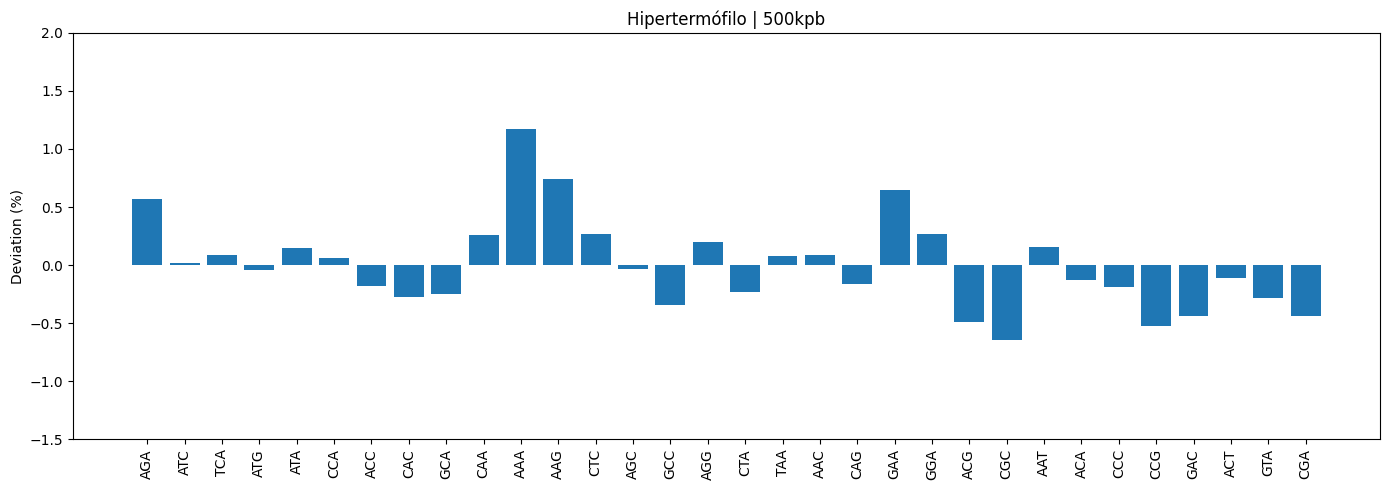

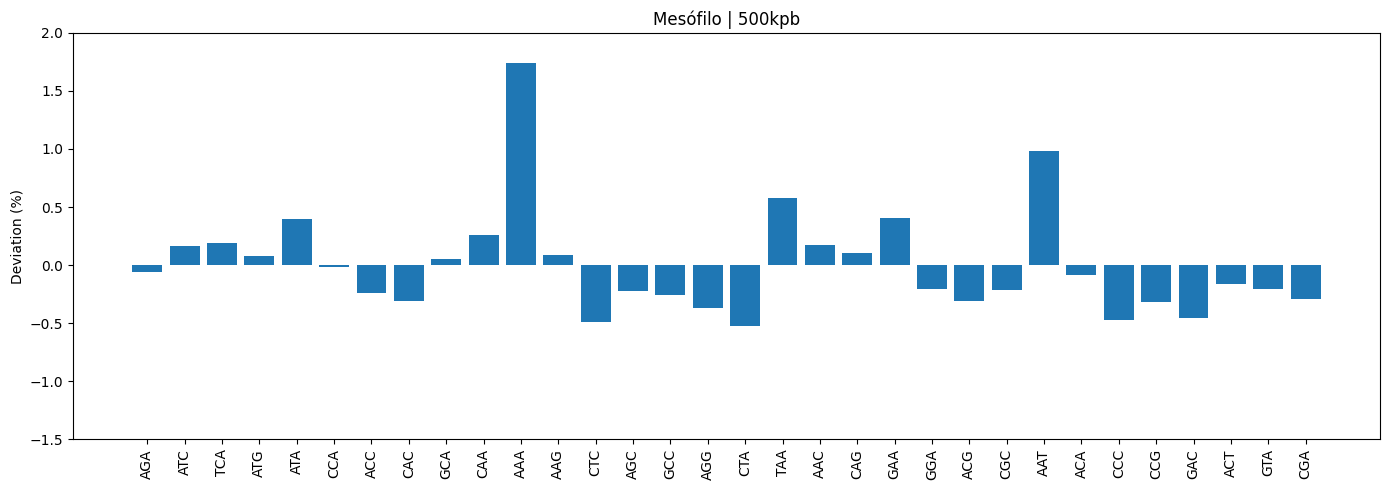

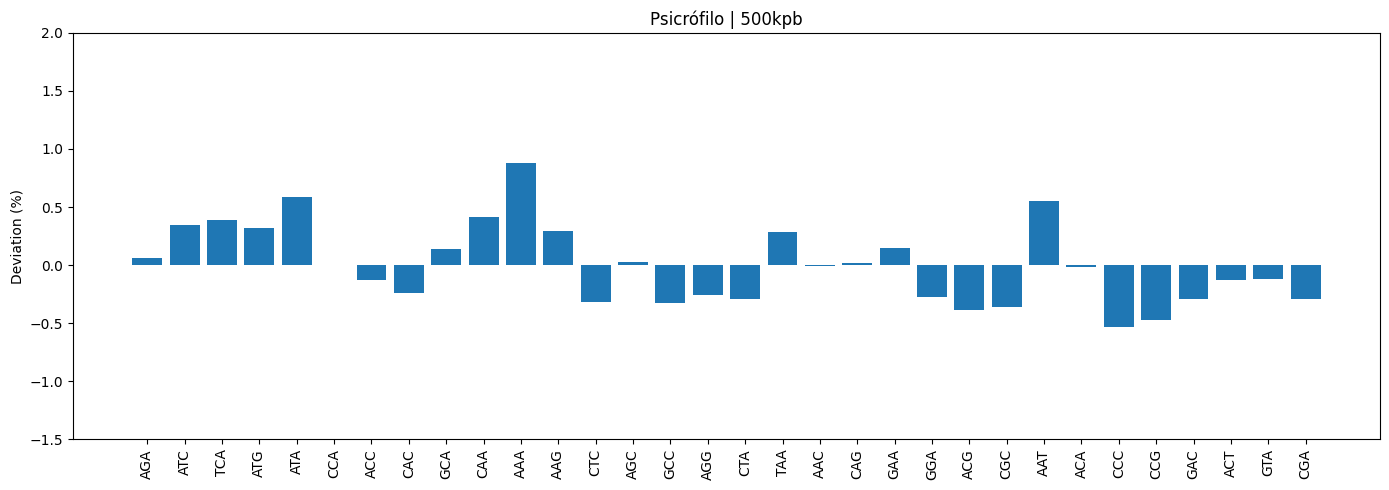

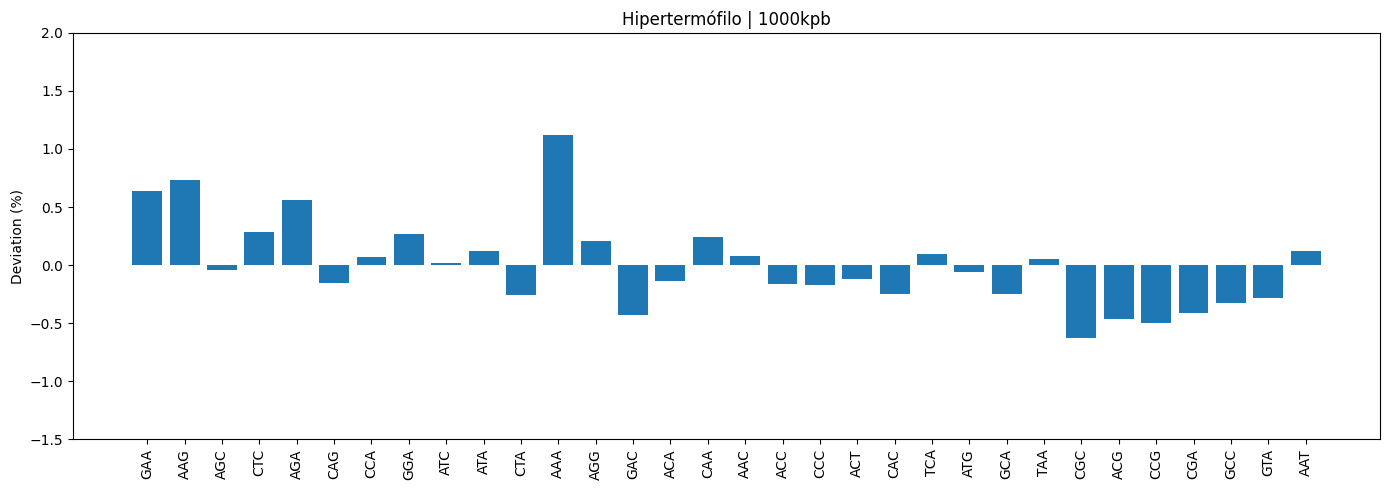

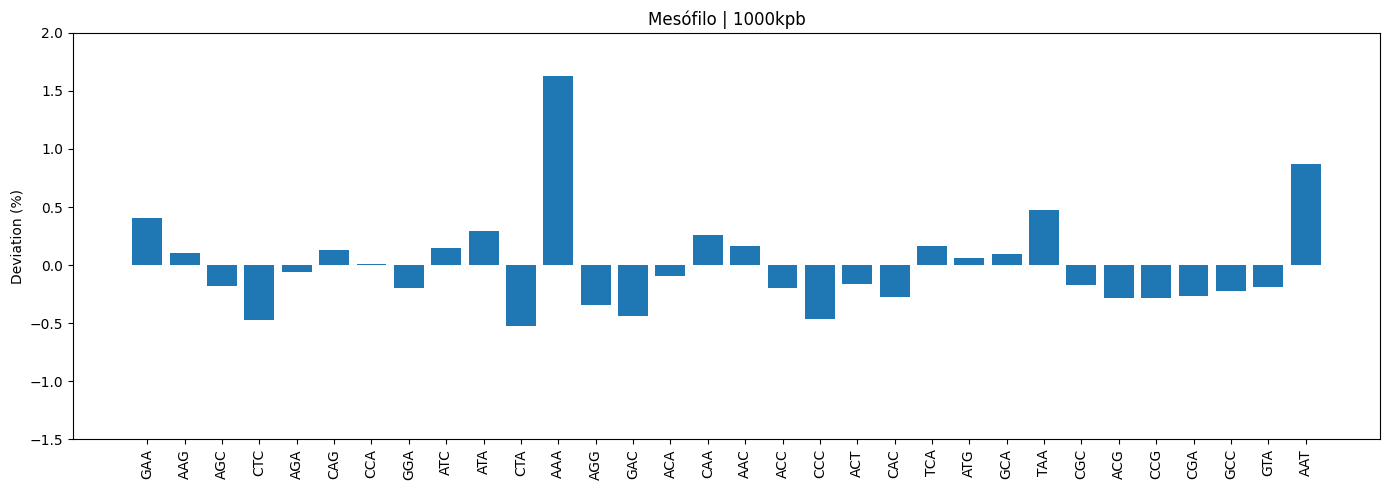

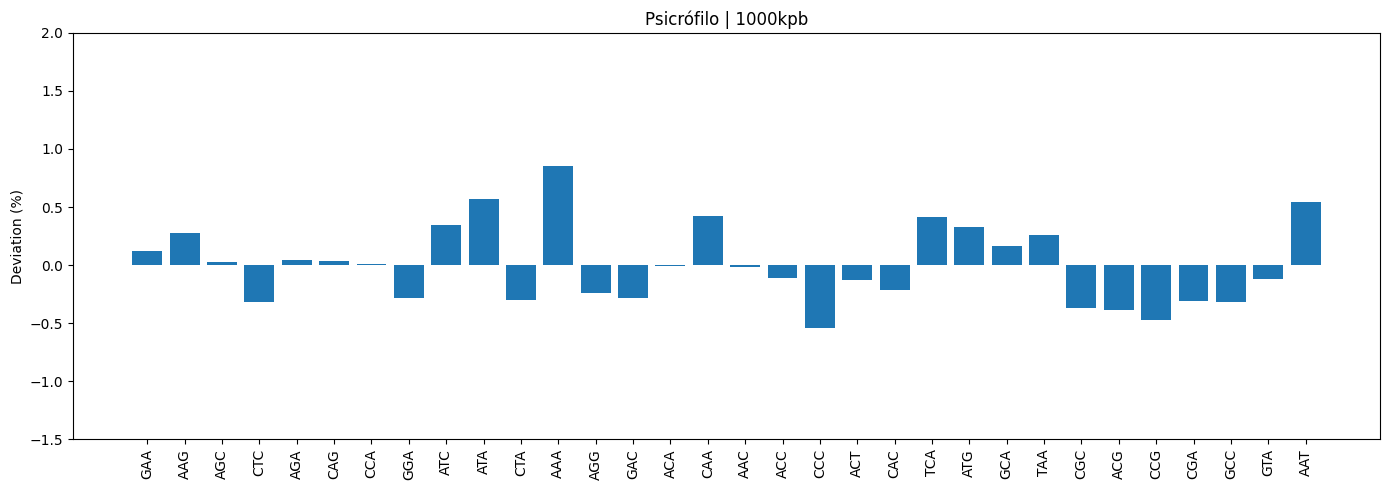

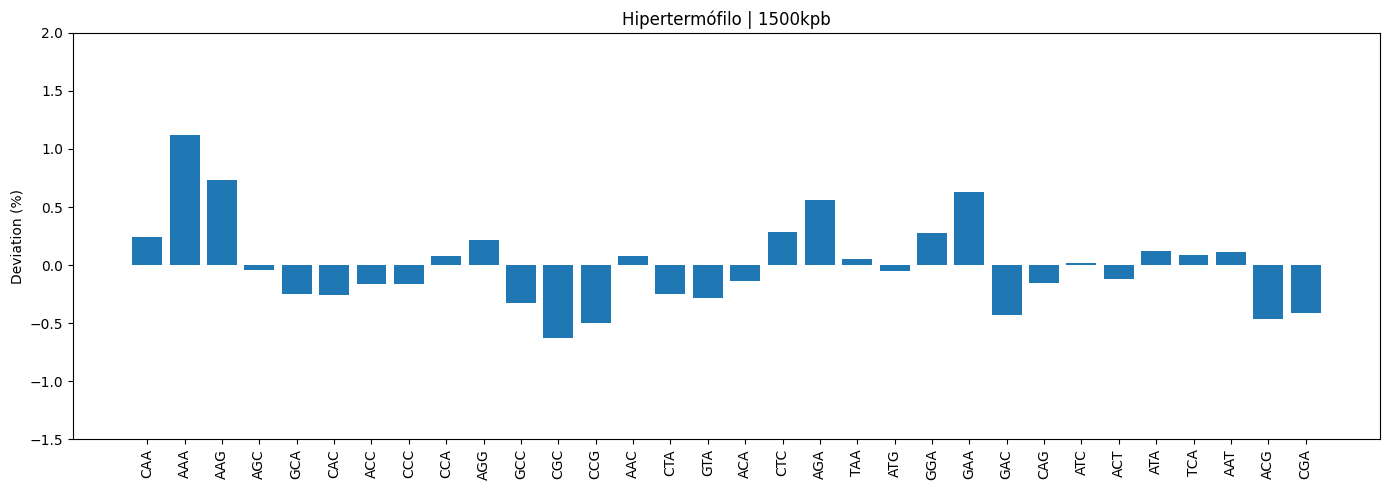

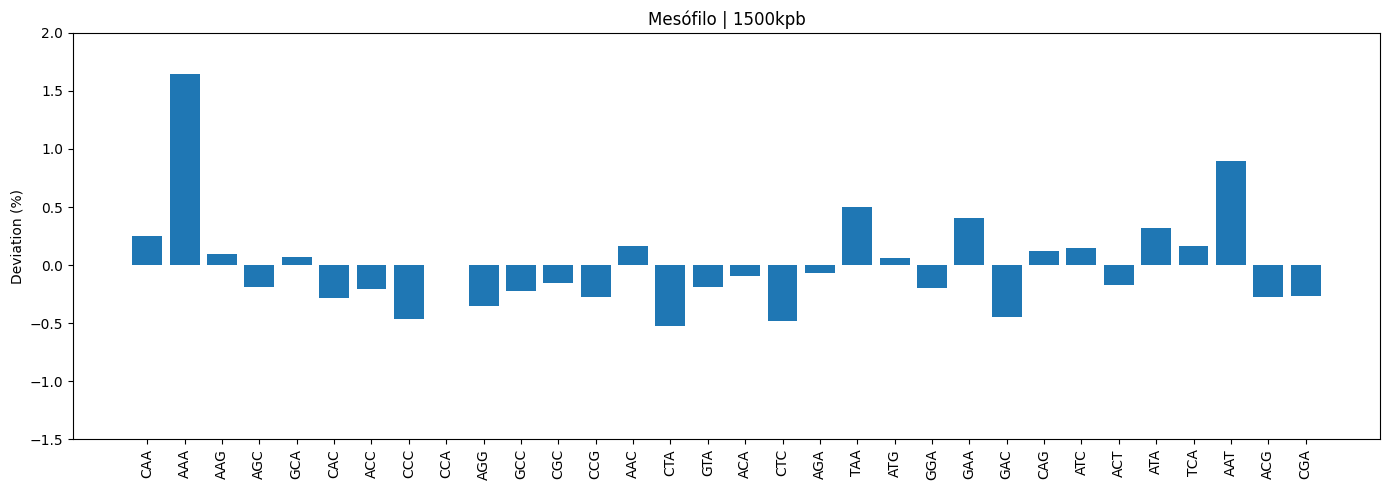

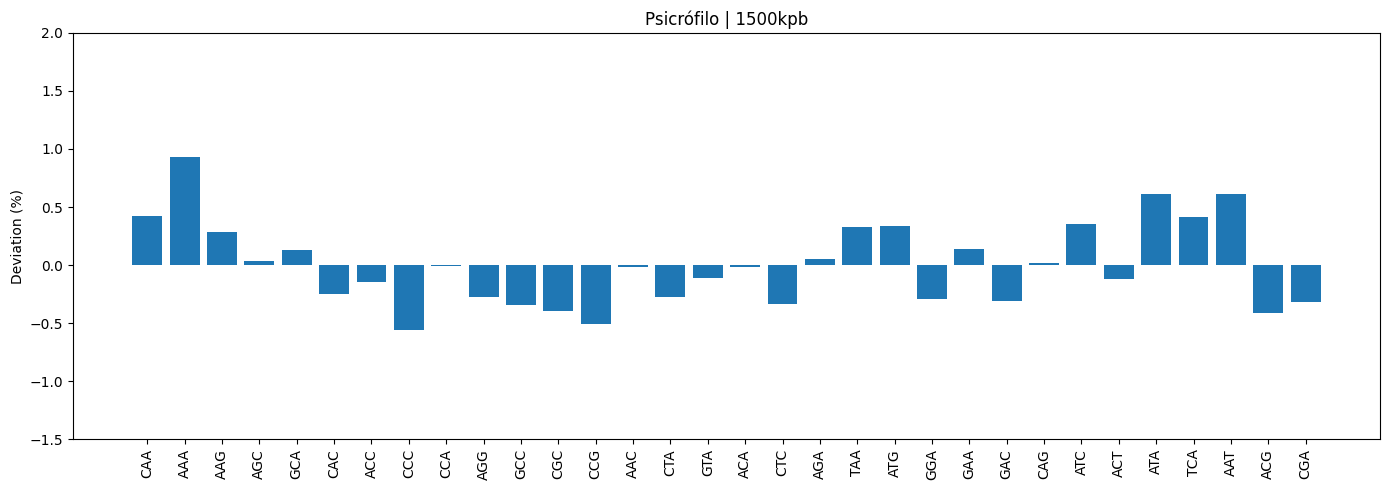

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

for tam in TAMANHOS_FRAGMENTO:
    nome_arq = f'resultados/vetores_frag{tam//1000}kbp_k3.csv'
    df = pd.read_csv(nome_arq)

    kmers = df.columns[3:]

    soma_ambiente = df.groupby("ambiente")[kmers].sum()

    for ambiente in soma_ambiente.index:
        valores = soma_ambiente.loc[ambiente]

        # média dentro do ambiente (entre k-mers)
        media = valores.mean()

        # desvio percentual interno
        deviation = (valores - media) / media

        plt.figure(figsize=(14, 5))
        plt.bar(deviation.index, deviation.values)

        plt.title(f"{ambiente} | {tam//1000}kpb")
        plt.ylabel("Deviation (%)")
        plt.xticks(rotation=90)

        plt.ylim(-1.5, 2)

        plt.tight_layout()
        plt.show()
        print()

# Matriz de Distância

In [46]:
import pandas as pd
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

### Distância Euclidiana
A normalização foi feita utilizando os valores dos k-mers de frequência máxima e mínima para cada k

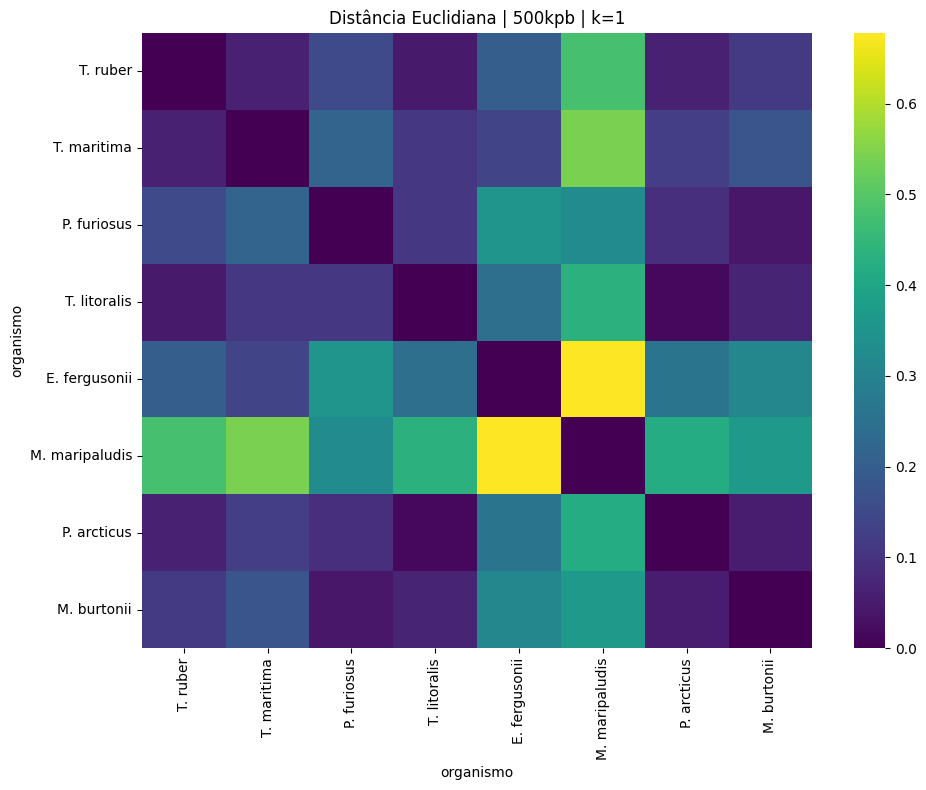

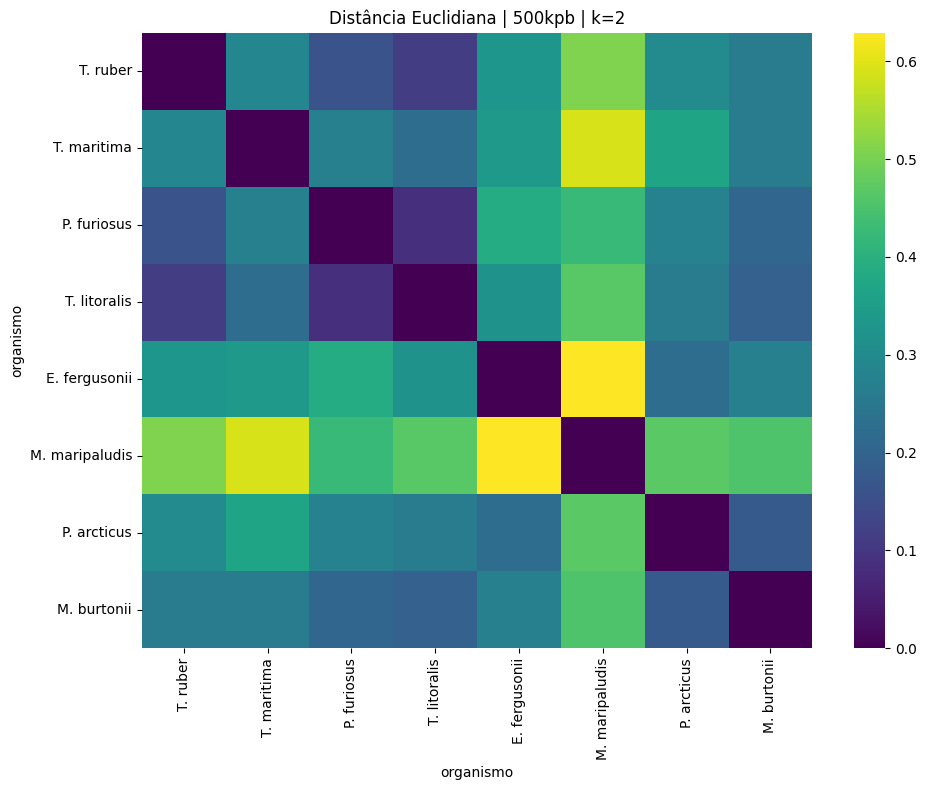

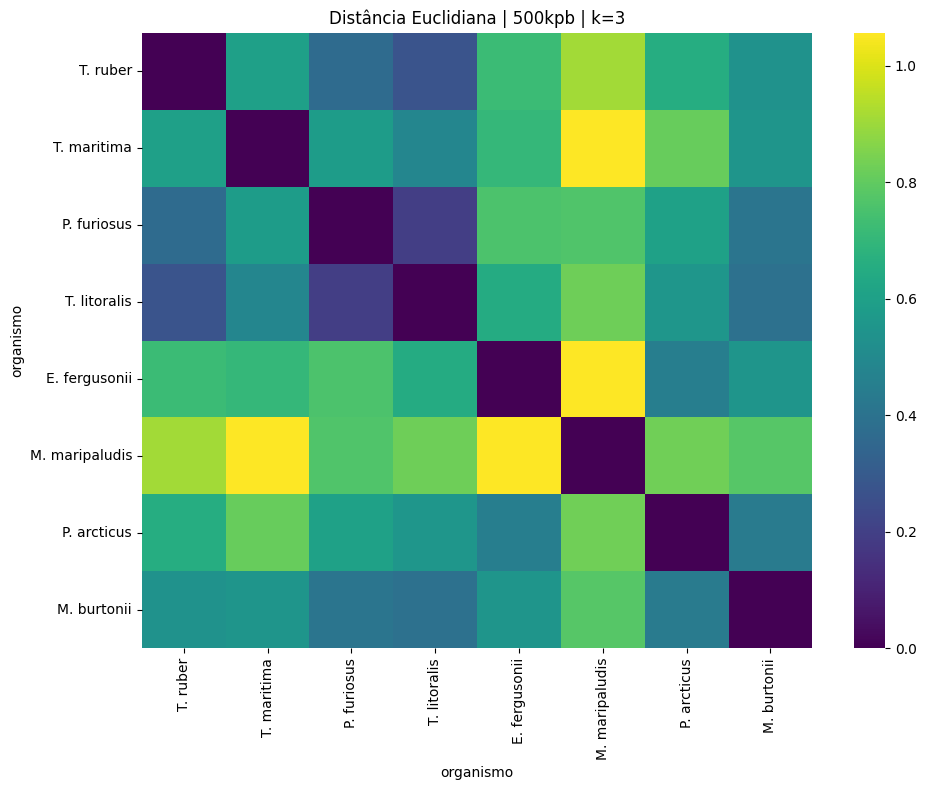

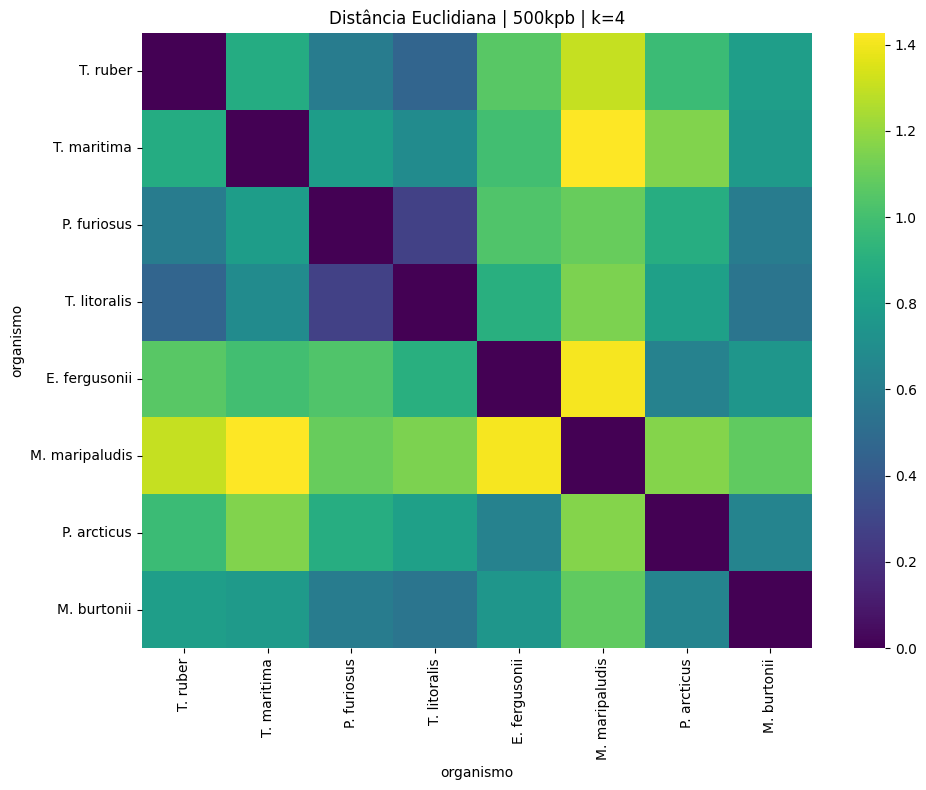

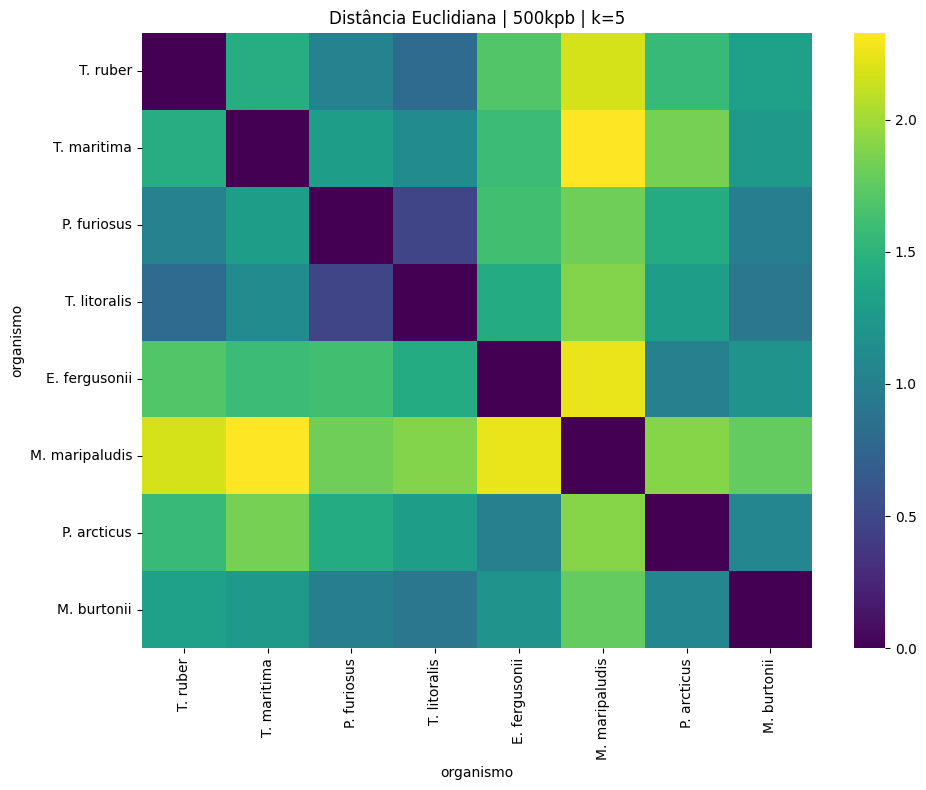

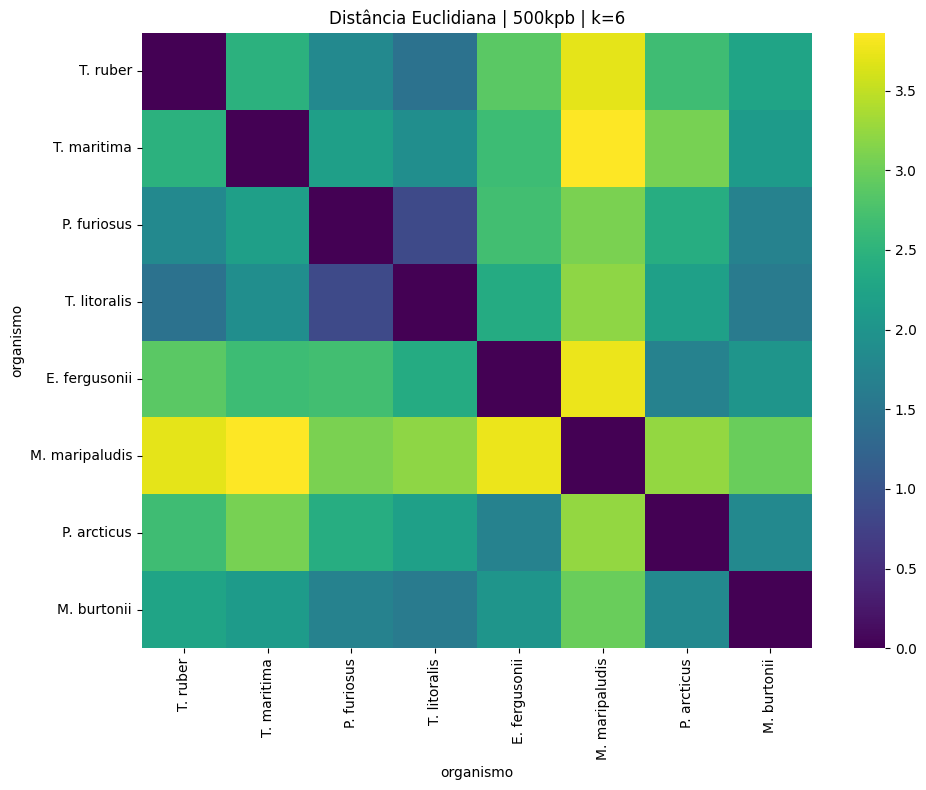

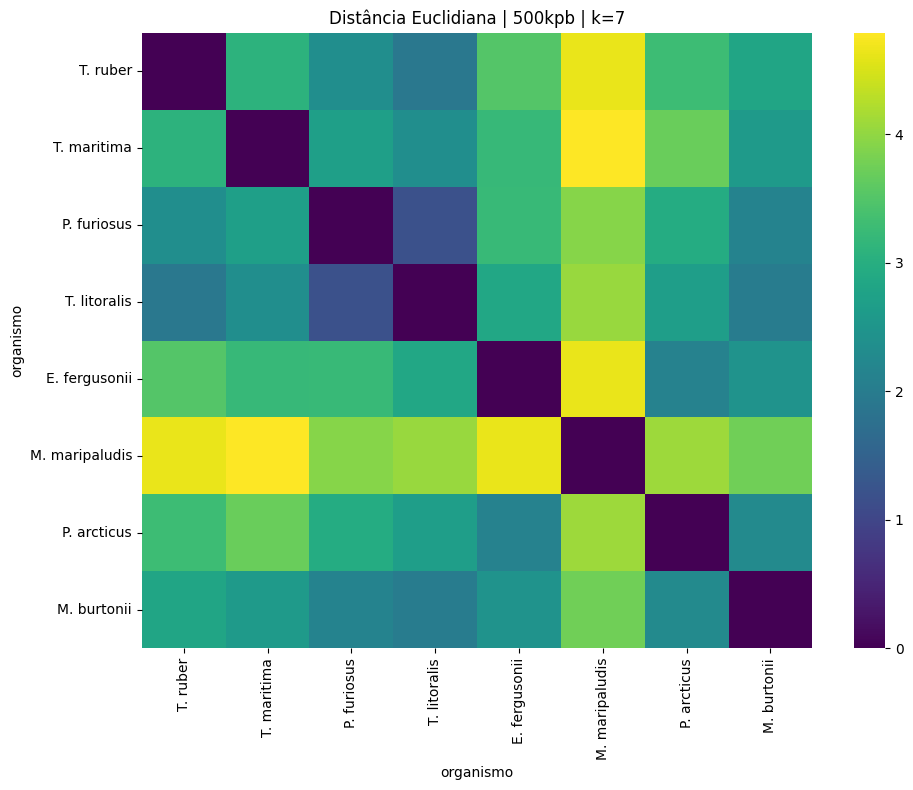

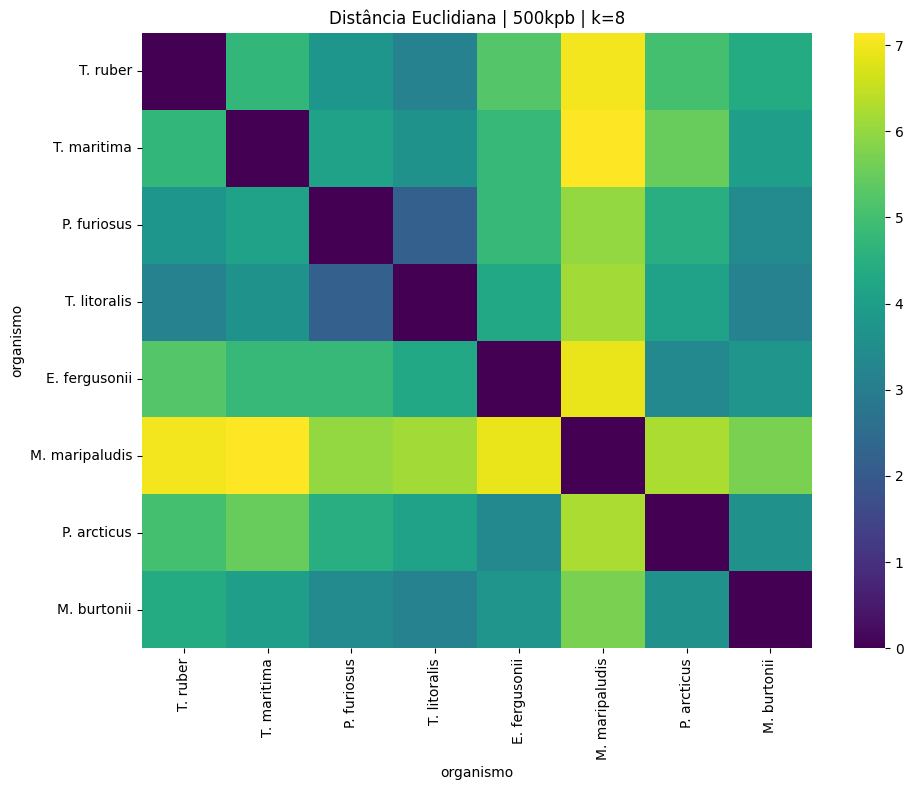

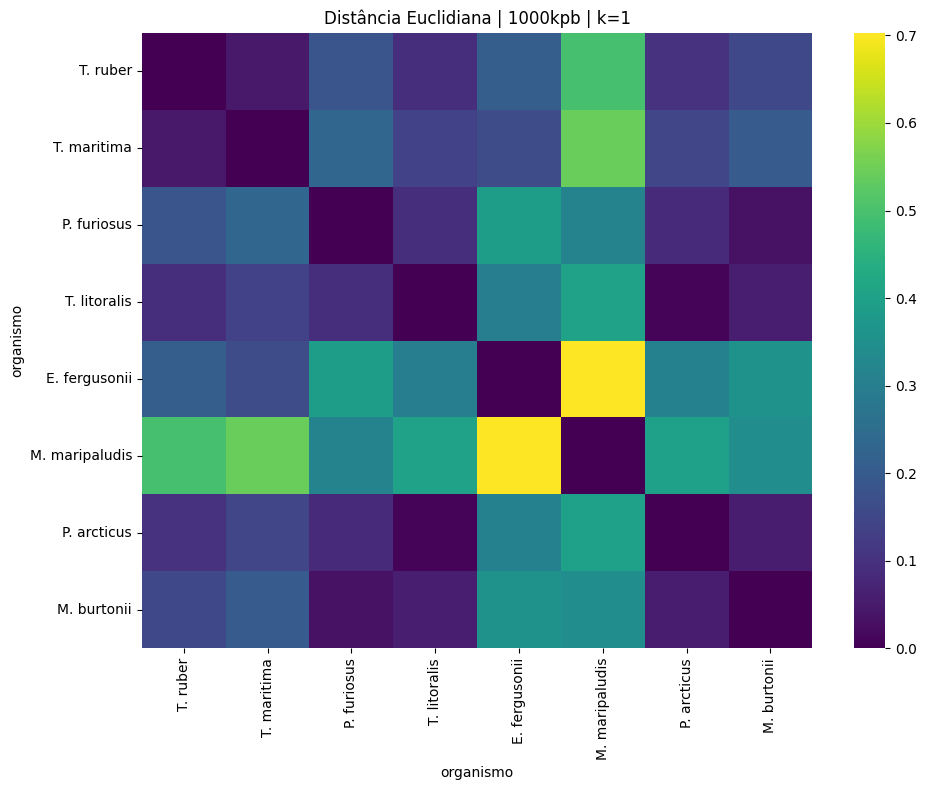

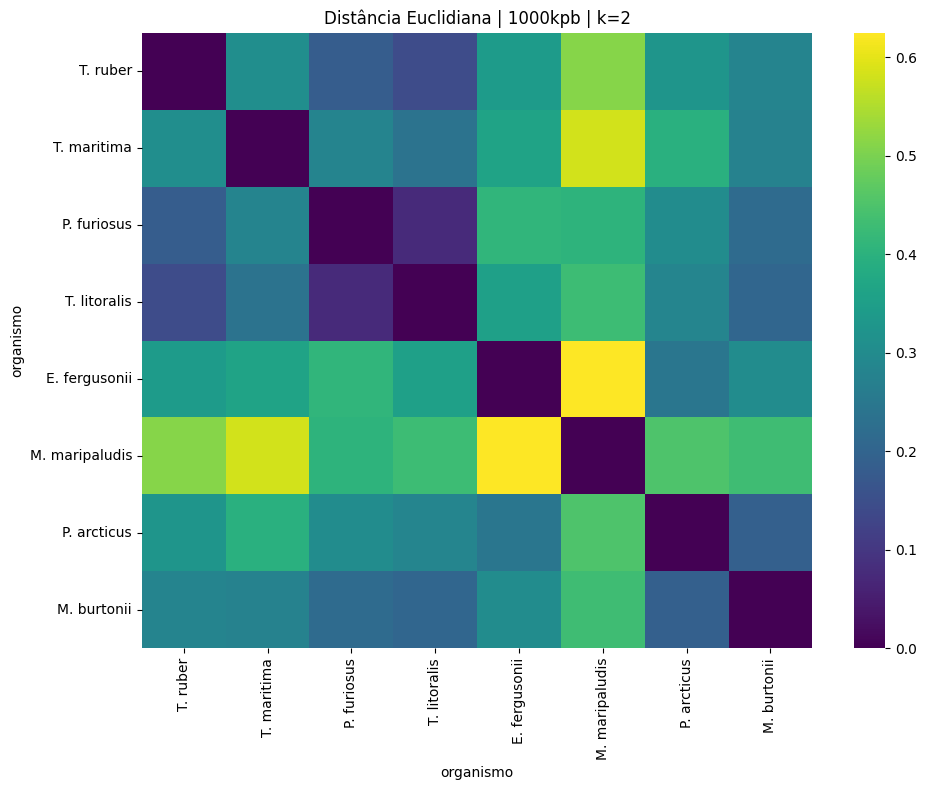

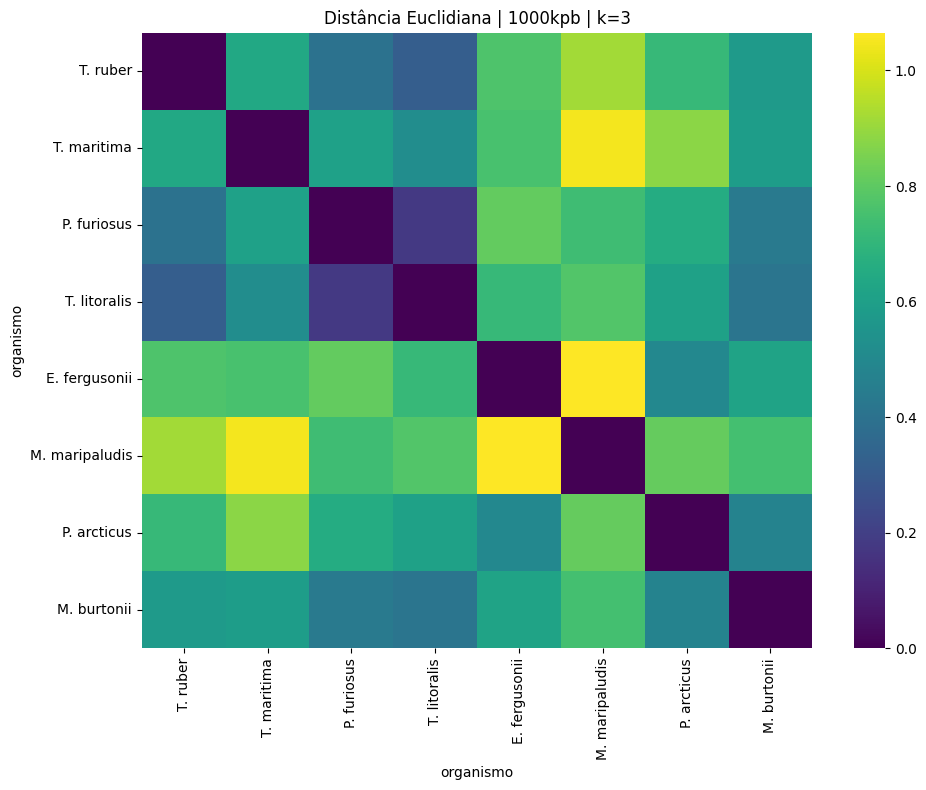

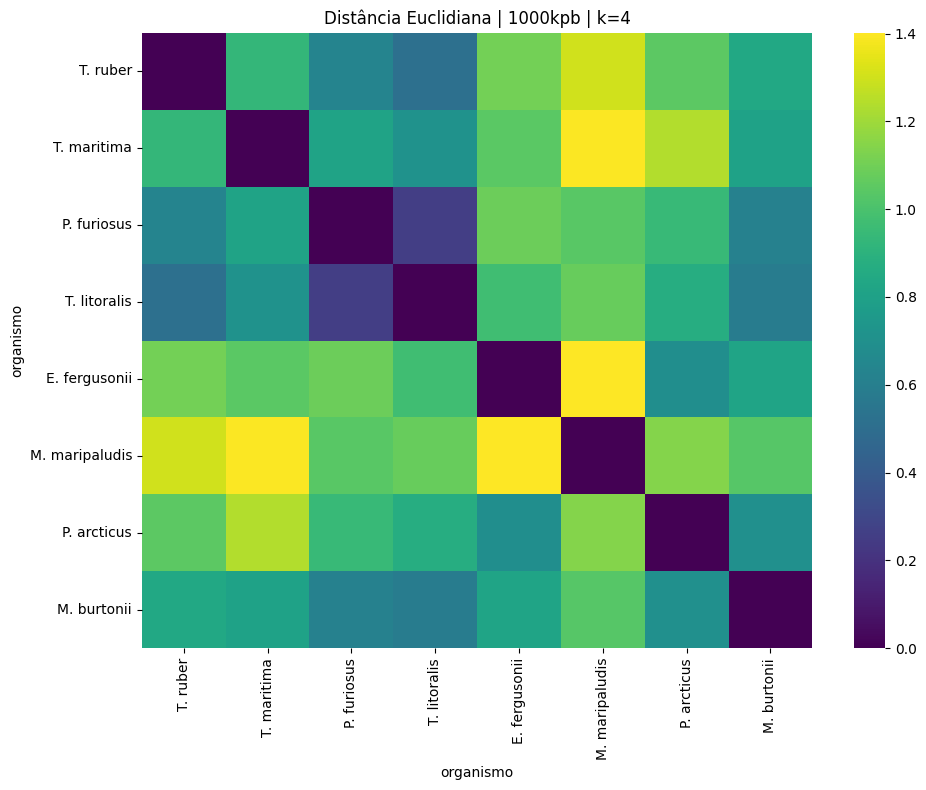

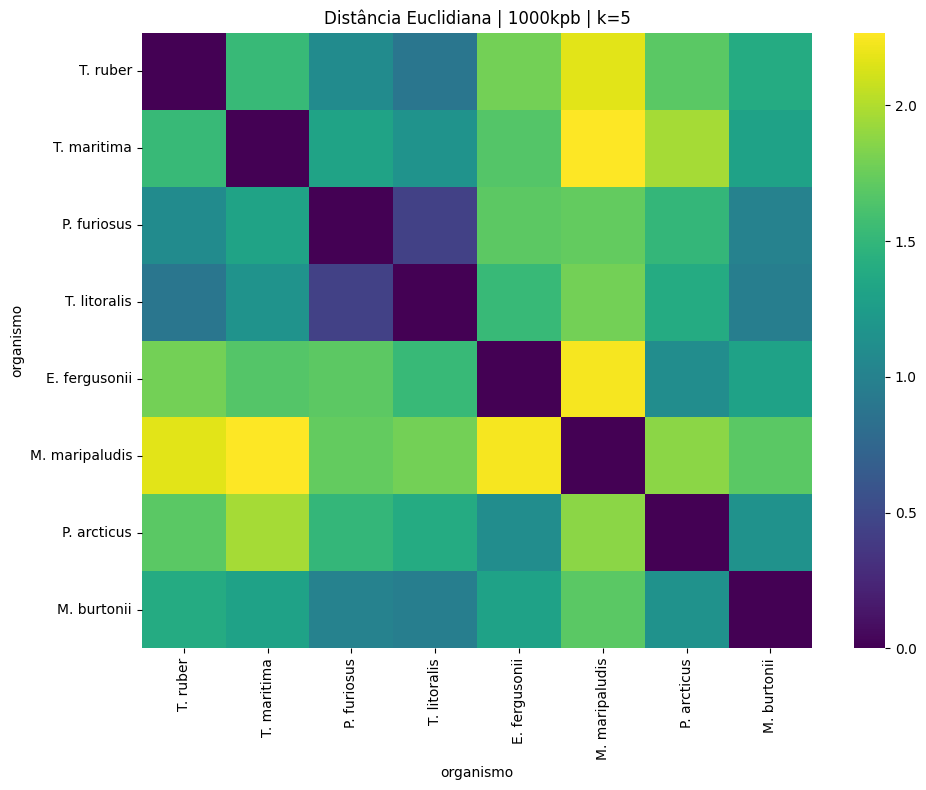

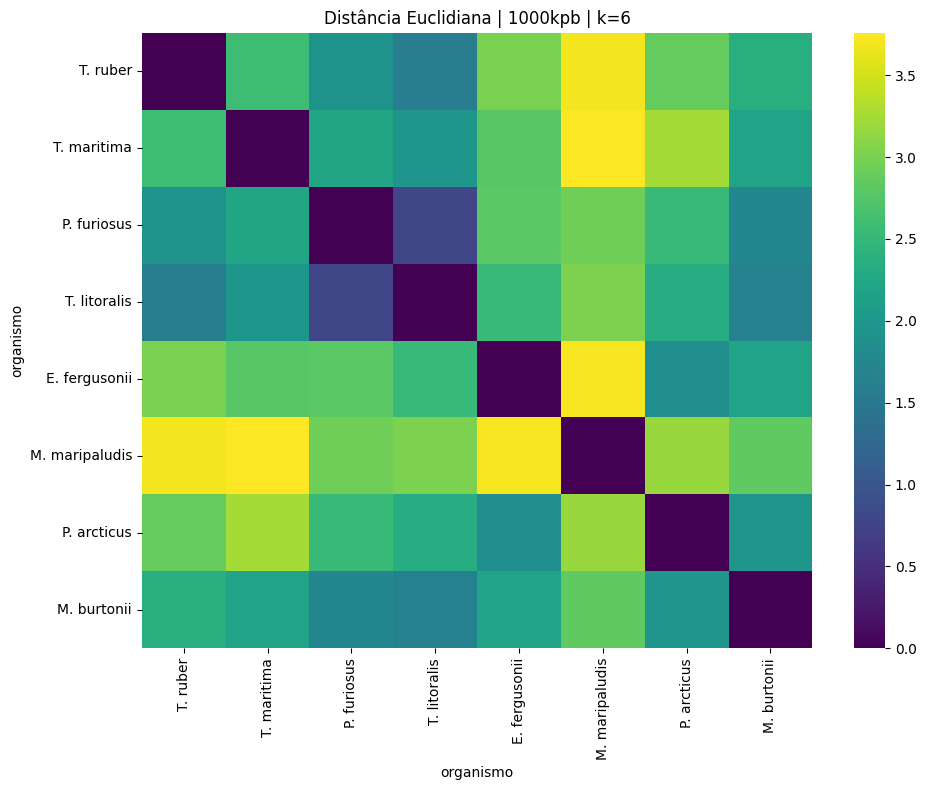

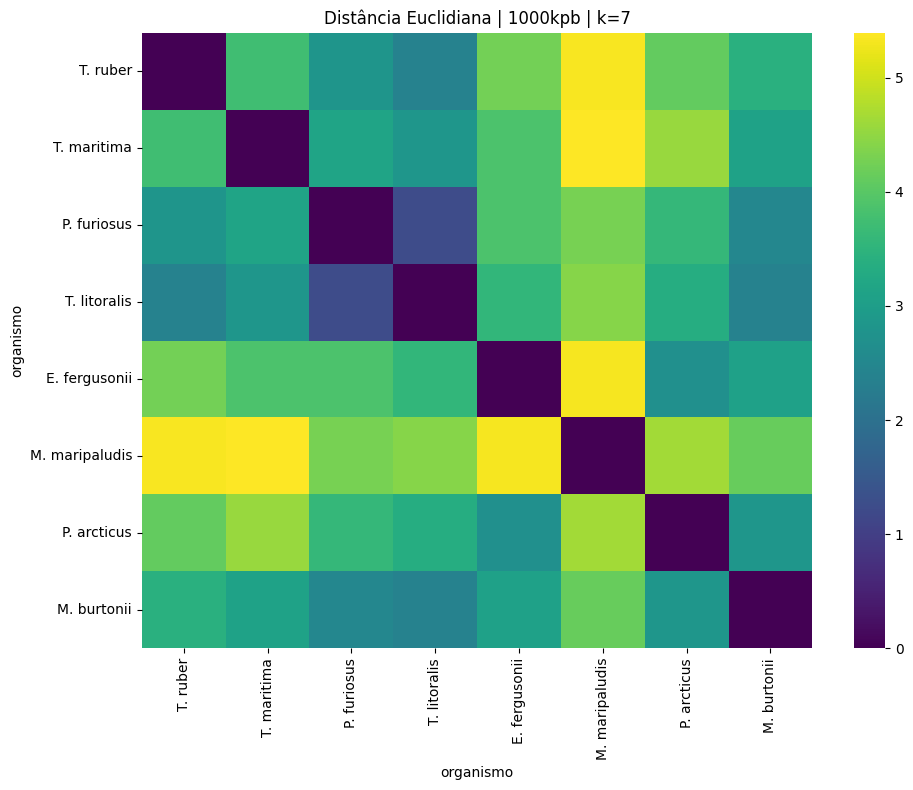

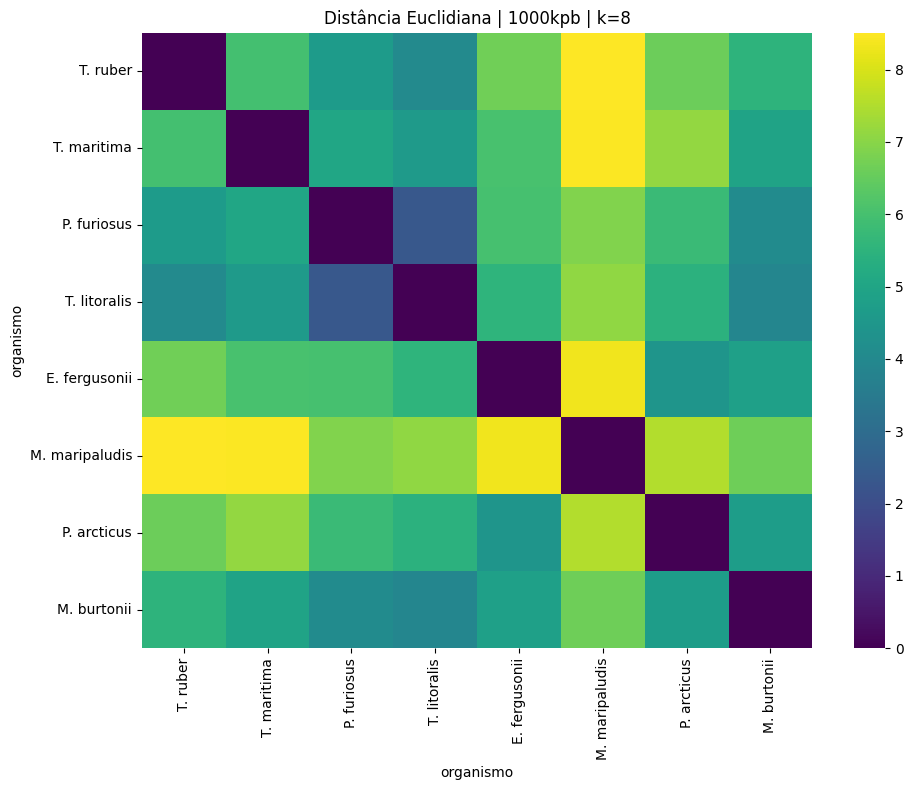

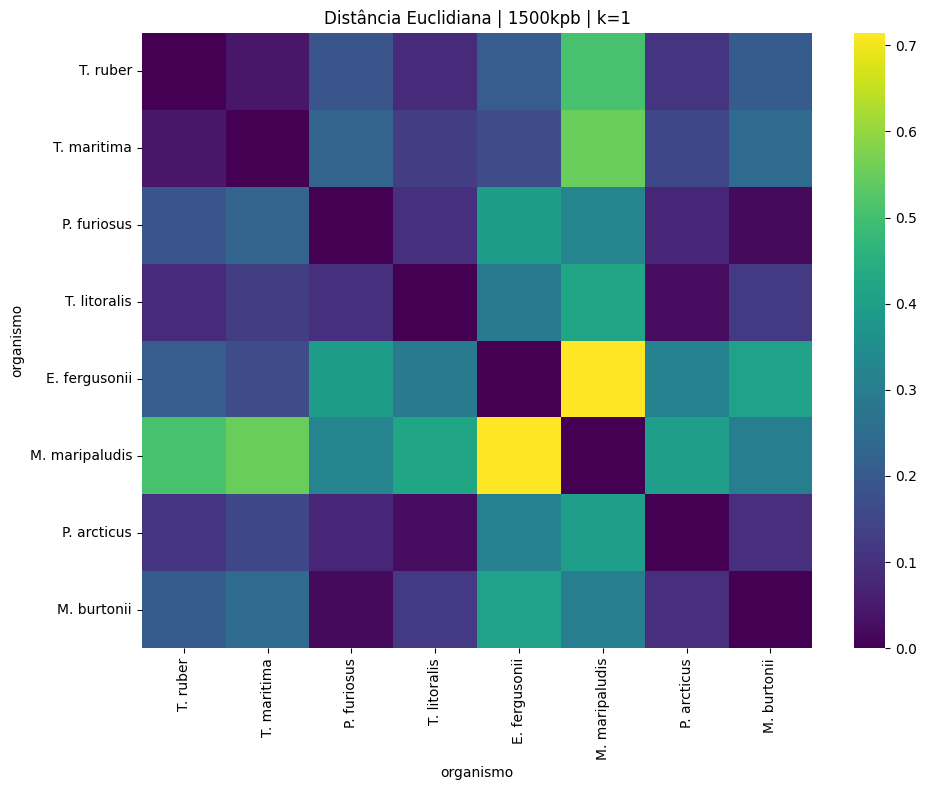

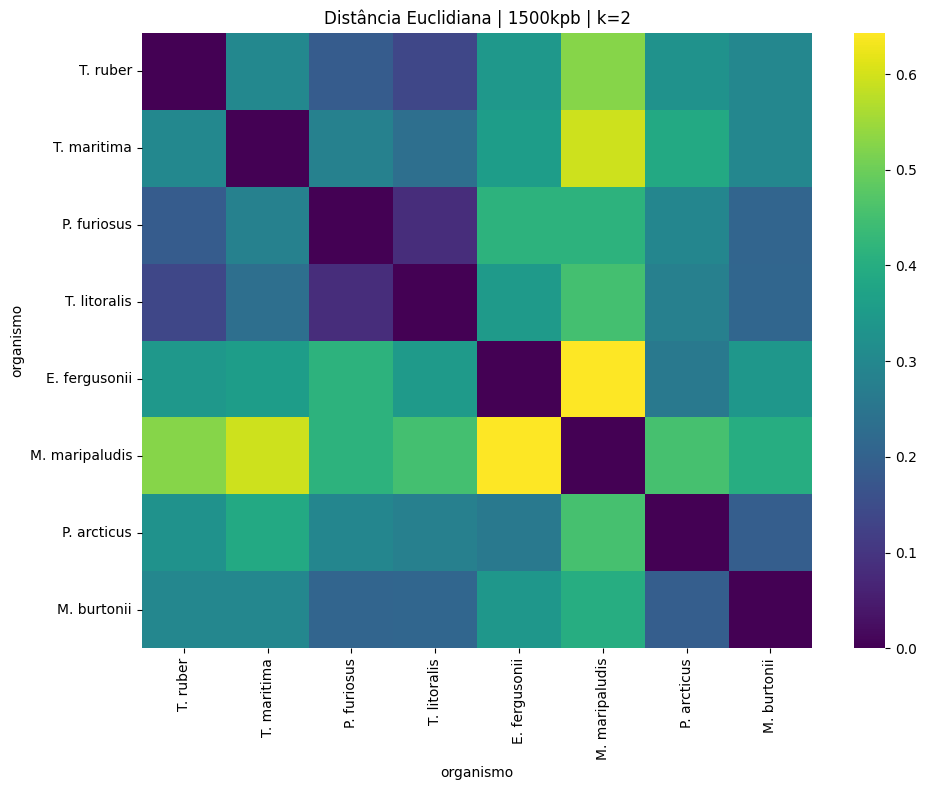

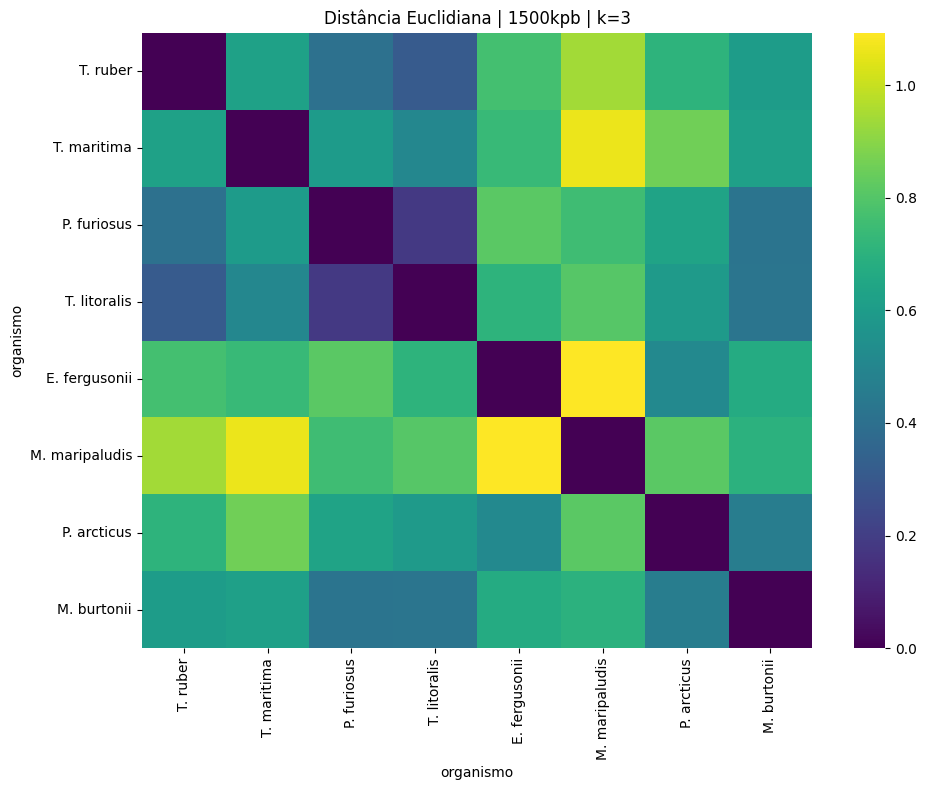

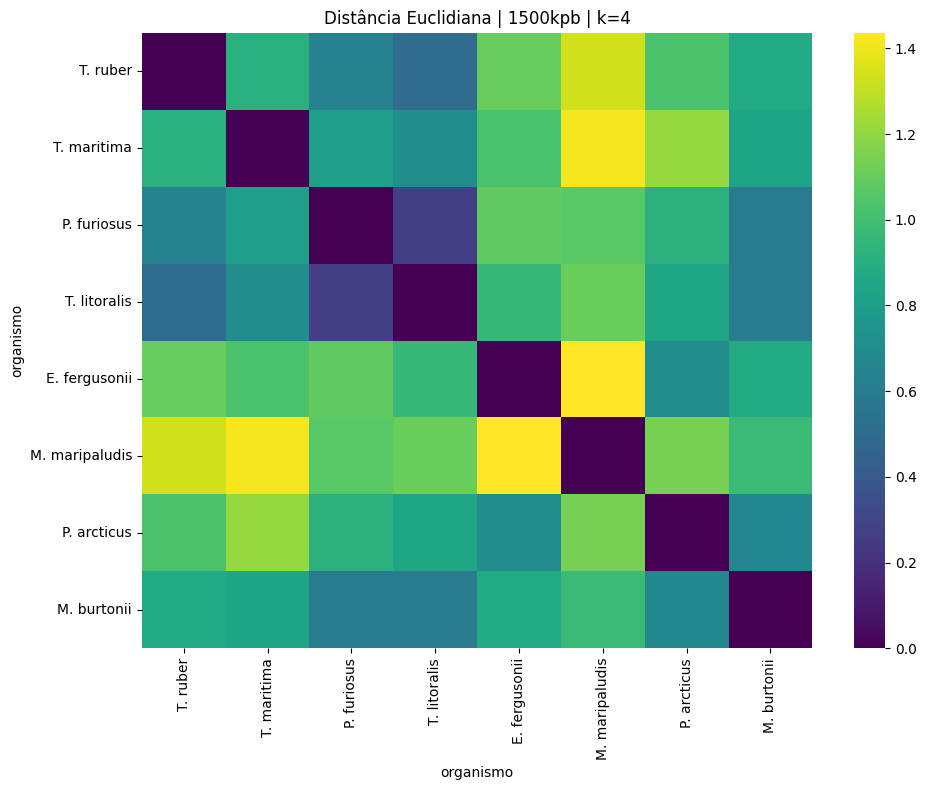

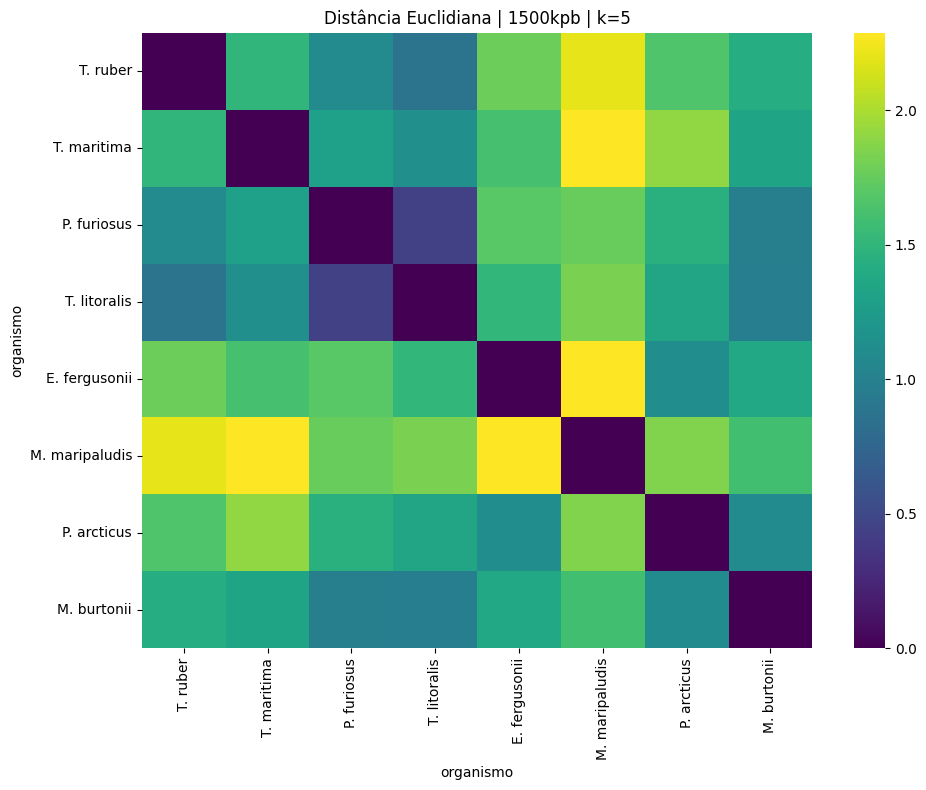

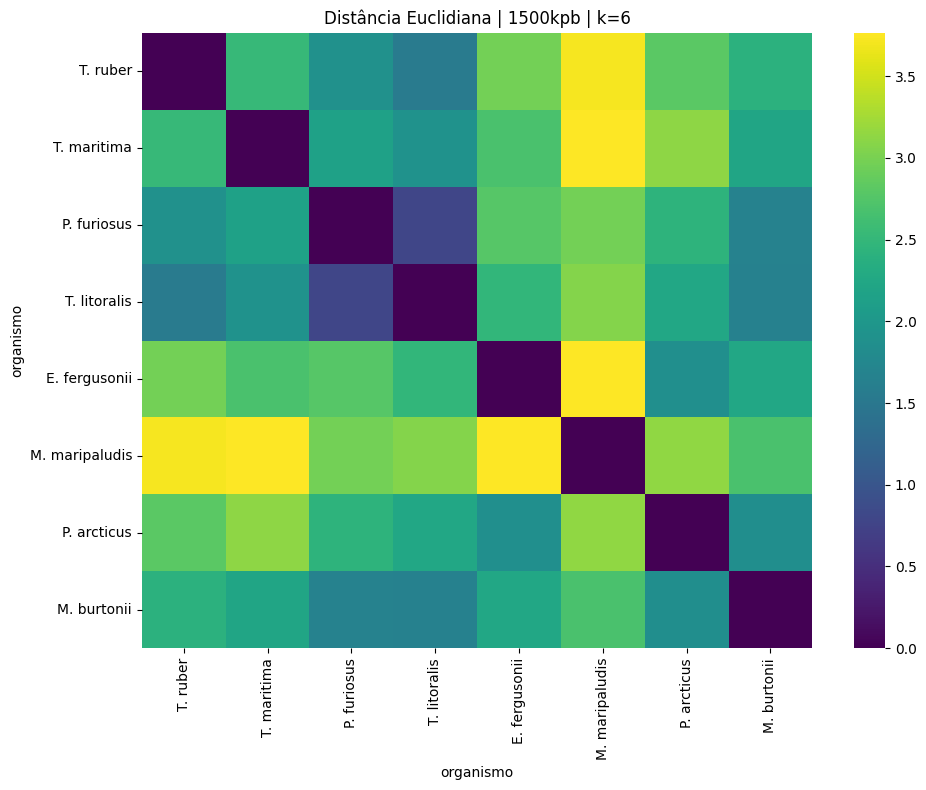

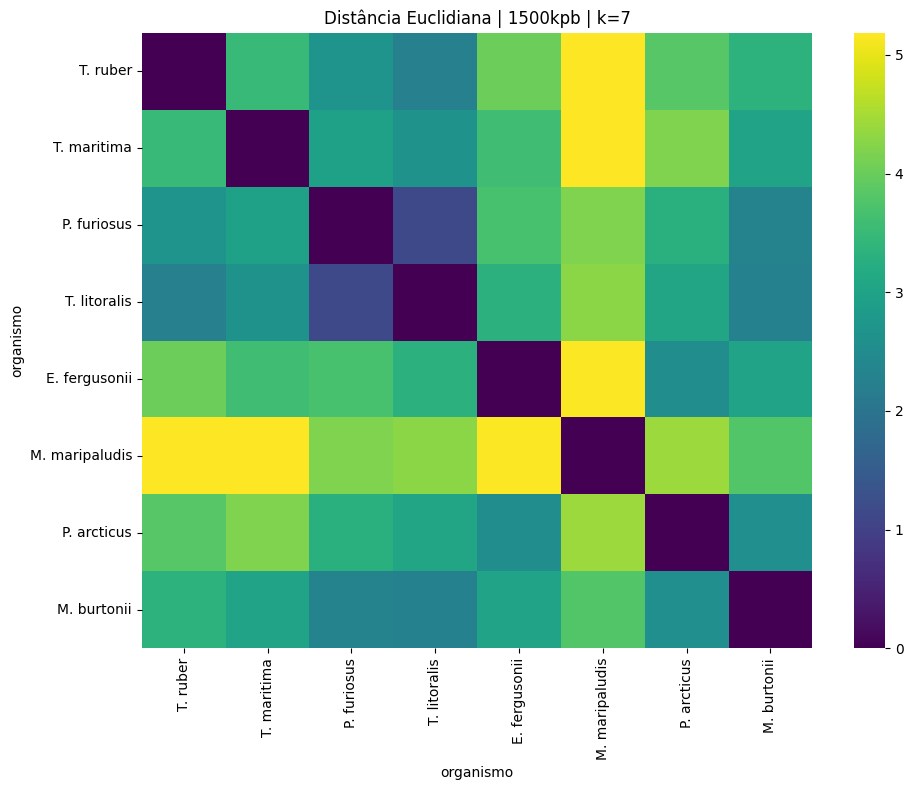

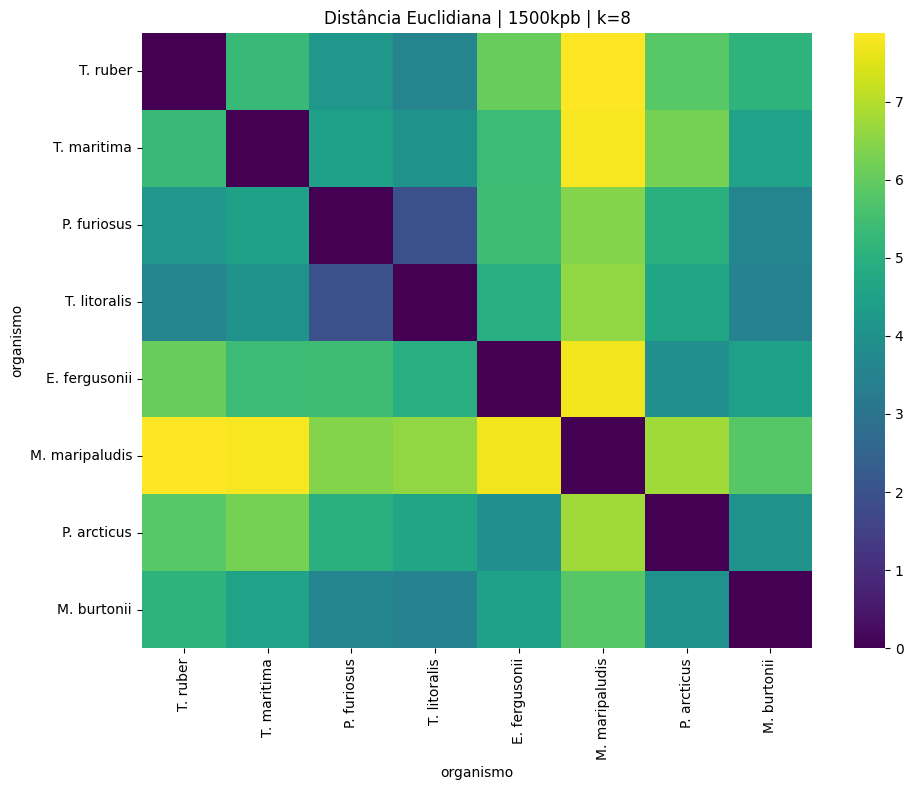

In [49]:
for tam in TAMANHOS_FRAGMENTO:
  for k in [1, 2, 3, 4, 5, 6, 7, 8]:
    nome_arq = f'resultados/vetores_frag{tam//1000}kbp_k{k}.csv'
    df = pd.read_csv(nome_arq)

    kmers = df.columns[3:]

    global_min = df[kmers].min().min()
    global_max = df[kmers].max().max()

    df[kmers] = (df[kmers] - global_min) / (global_max - global_min)

    matriz = squareform(pdist(df[kmers], metric="euclidean"))

    df_dist = pd.DataFrame(
        matriz,
        index=df["organismo"],
        columns=df["organismo"]
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(df_dist, cmap="viridis")

    plt.title(f"Distância Euclidiana | {tam//1000}kpb | k={k}")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

    print()

### Diferença par a par entre k-mers entre pares de organismos (normalização de kmer a kmer)
O conjunto de kmers canônicos (vetor) são considerados a assinatura genômica no artigo, a representação dele não é uma matriz, mas uma única "linha".
> Millán Arias P et al. Environment and taxonomy shape the genomic signature of prokaryotic extremophiles. Sci Rep. 2023;13:16105. https://doi.org/10.1038/s41598-023-42518-y

Normalizamos os valores de coluna a coluna e subtraímos coluna por coluna para ver a diferença da assinatura entre organismos.

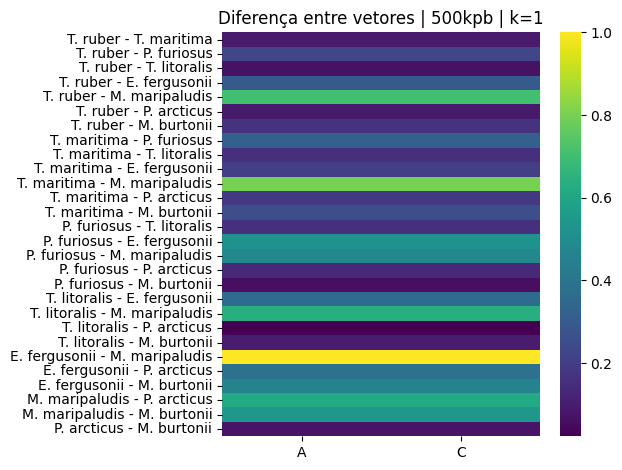

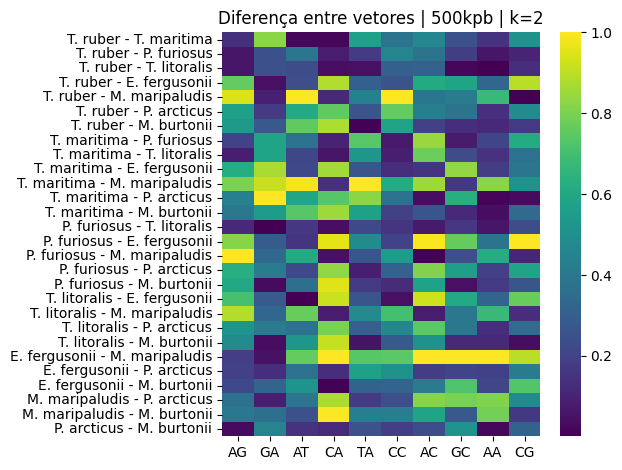

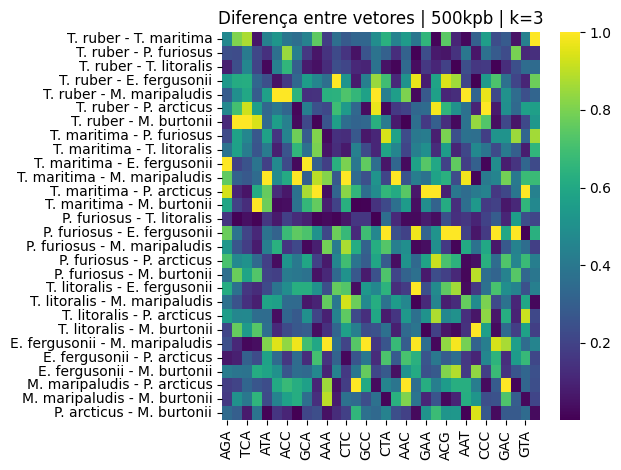

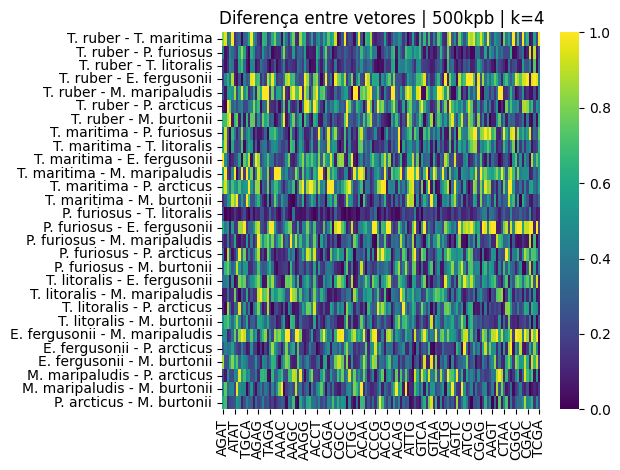

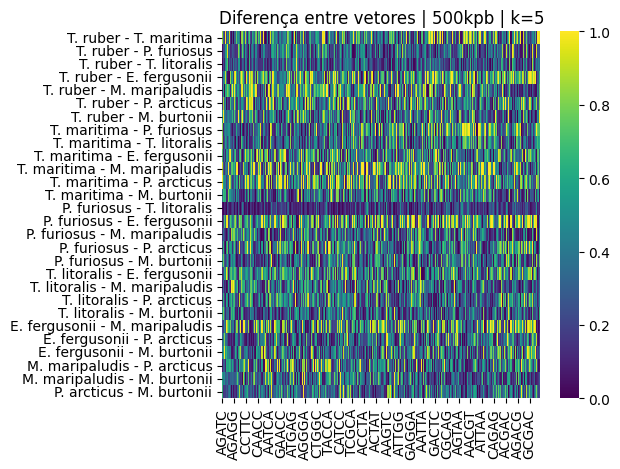

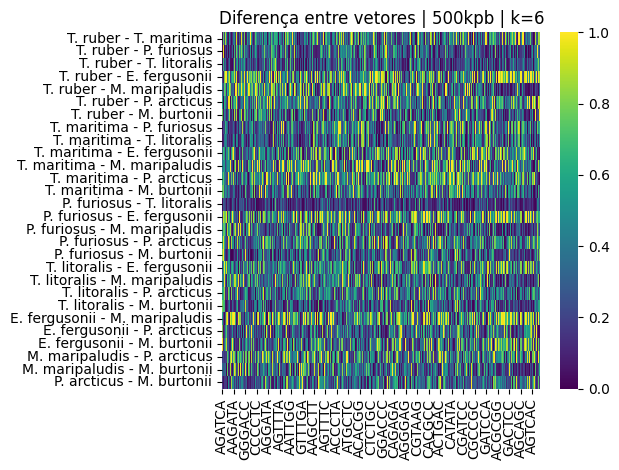

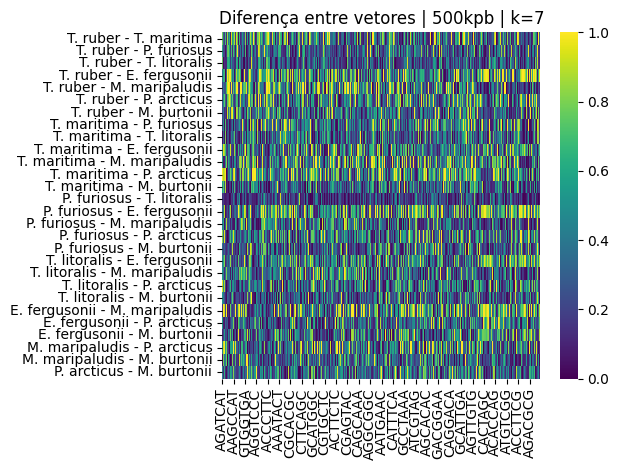

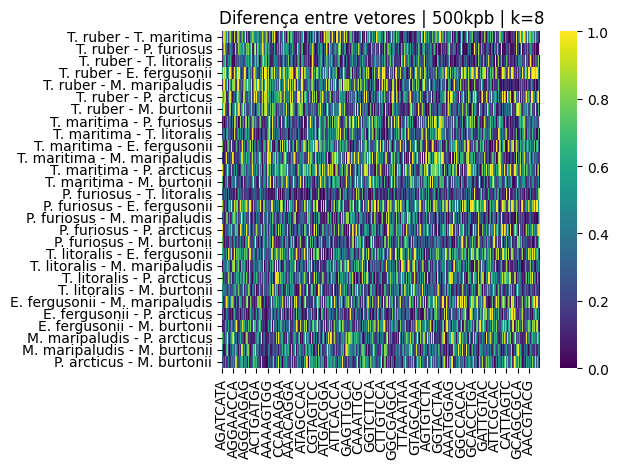

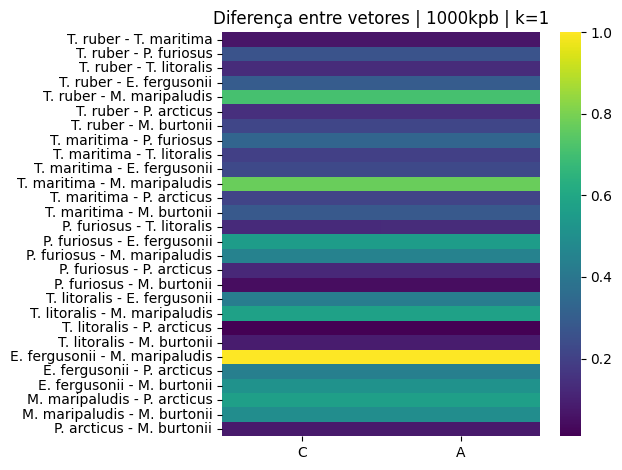

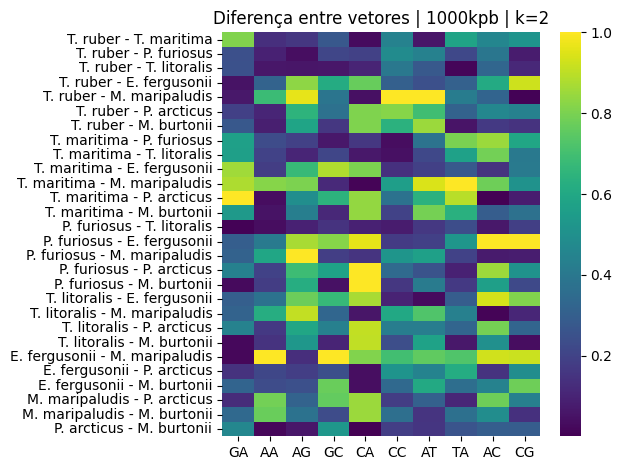

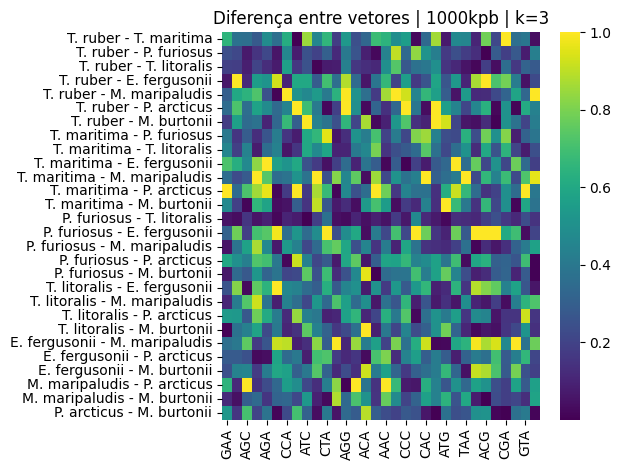

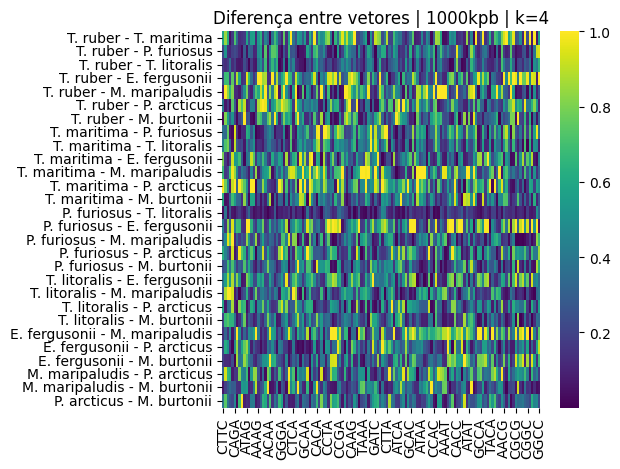

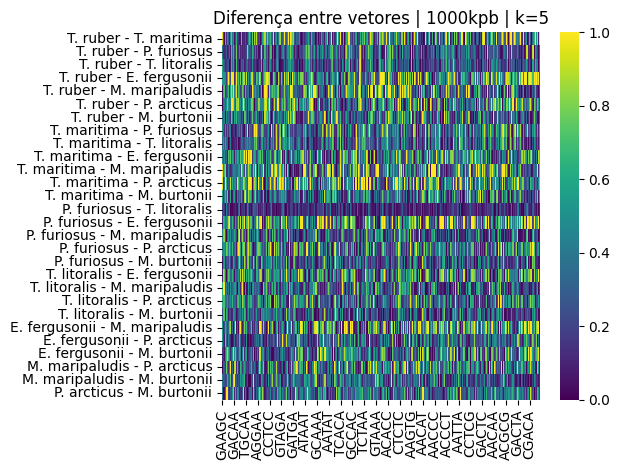

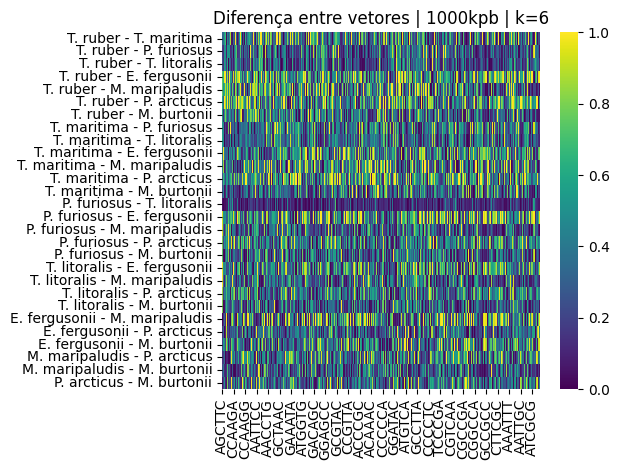

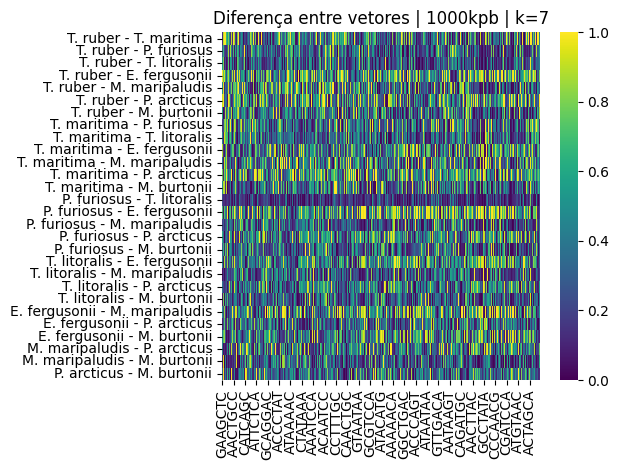

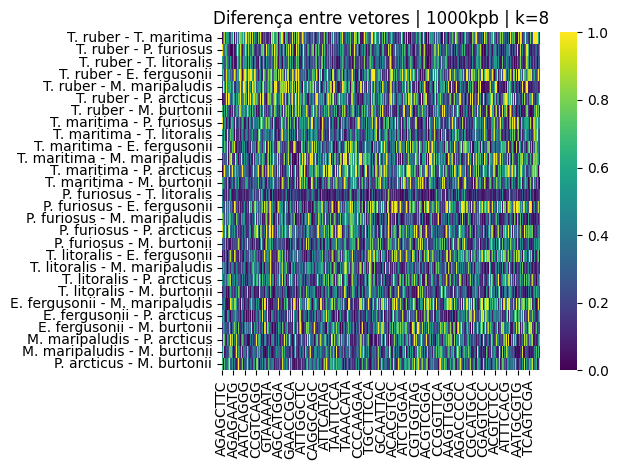

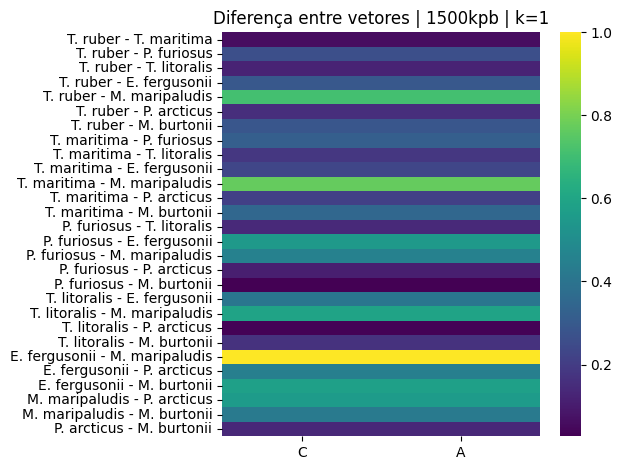

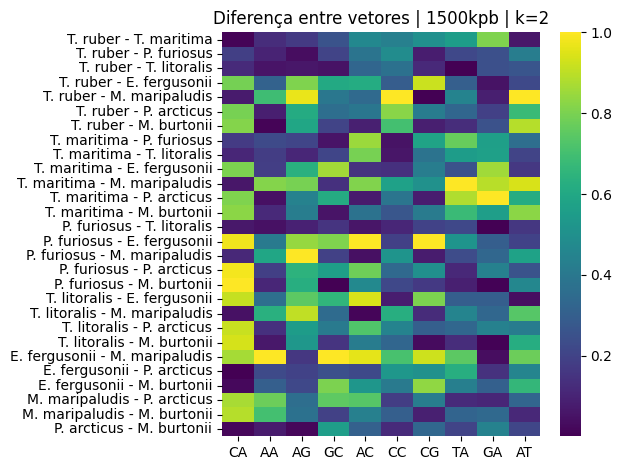

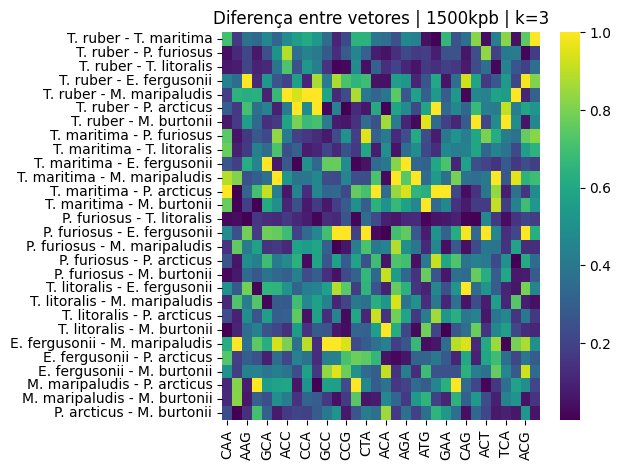

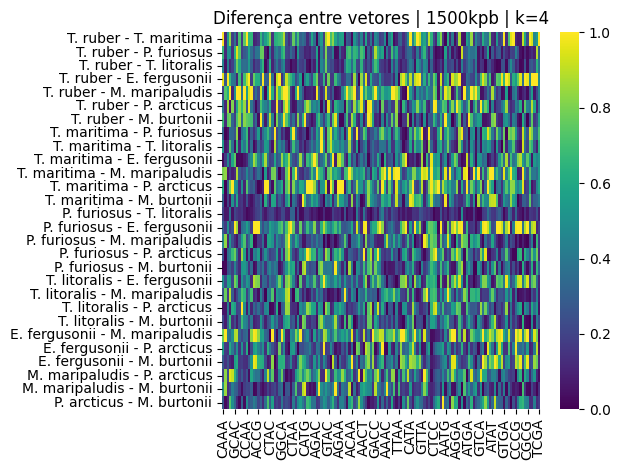

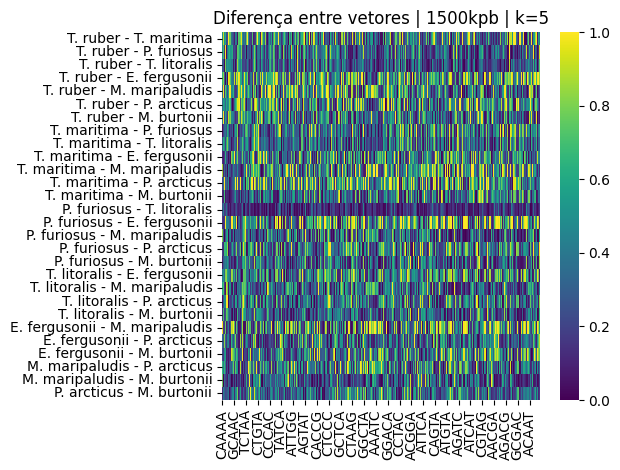

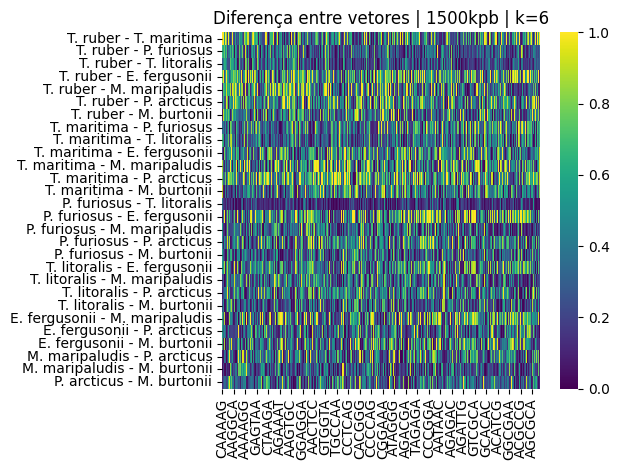

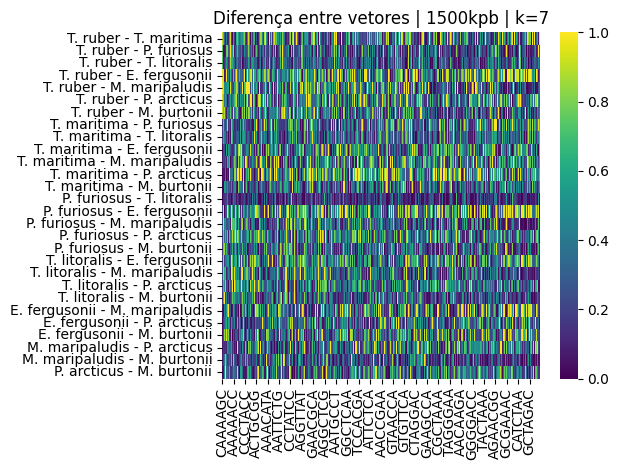

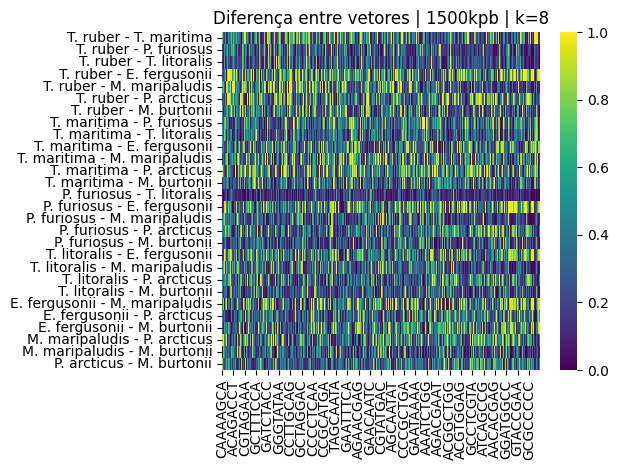

In [47]:
for tam in TAMANHOS_FRAGMENTO:
  for k in [1, 2, 3, 4, 5, 6, 7, 8]:
    nome_arq = f'resultados/vetores_frag{tam//1000}kbp_k{k}.csv'
    df = pd.read_csv(nome_arq)
    kmers = df.columns[3:]
    df[kmers] = (df[kmers] - df[kmers].min()) / (df[kmers].max() - df[kmers].min())

    df_result = pd.DataFrame({
        f"{df.loc[i, 'organismo']} - {df.loc[j, 'organismo']}": (df.loc[i, kmers] - df.loc[j, kmers]).abs()
        for i, j in itertools.combinations(df.index, 2)
    }).T

    df_result = df_result.astype(float)

    ax = sns.heatmap(df_result, cmap="viridis")
    ax.set_yticks([i + 0.5 for i in range(len(df_result.index))])
    ax.set_yticklabels(df_result.index, rotation=0)
    plt.title(f"Diferença entre vetores | {tam//1000}kpb | k={k}")

    plt.tight_layout()
    plt.show()

    print()

### Diferença par a par entre k-mers entre pares de organismos (normalização global)
O conjunto de kmers canônicos (vetor) são considerados a assinatura genômica no artigo, a representação dele não é uma matriz, mas uma única "linha".
> Millán Arias P et al. Environment and taxonomy shape the genomic signature of prokaryotic extremophiles. Sci Rep. 2023;13:16105. https://doi.org/10.1038/s41598-023-42518-y

Normalizamos os valores globalmente para cada arquivo e subtraímos coluna por coluna para ver a diferença da assinatura entre organismos.

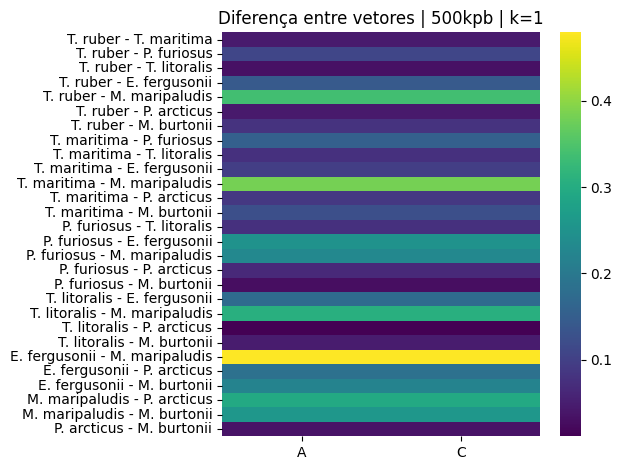

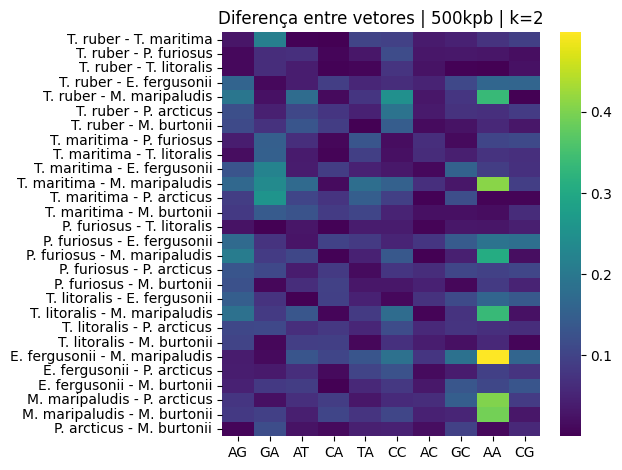

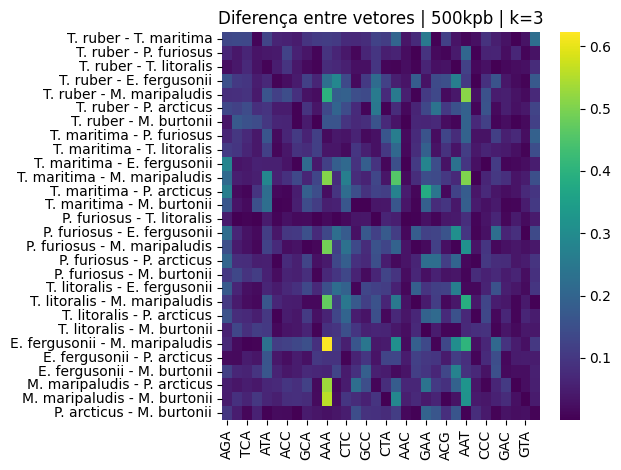

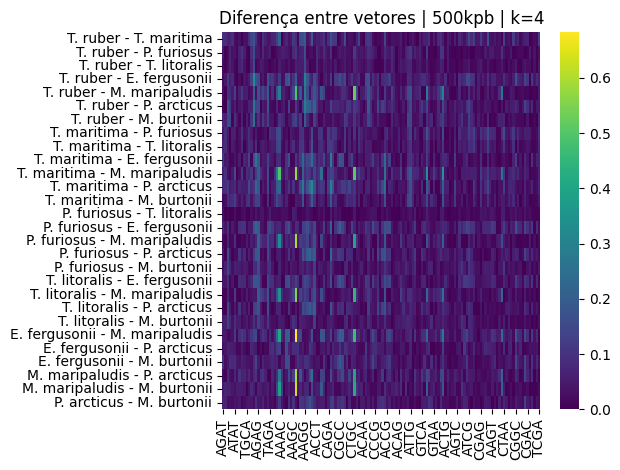

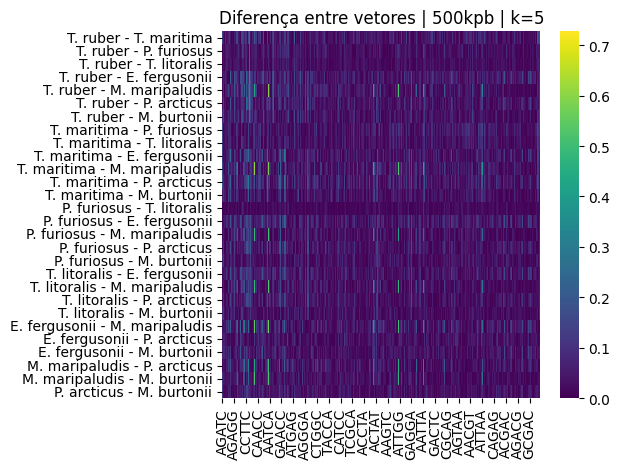

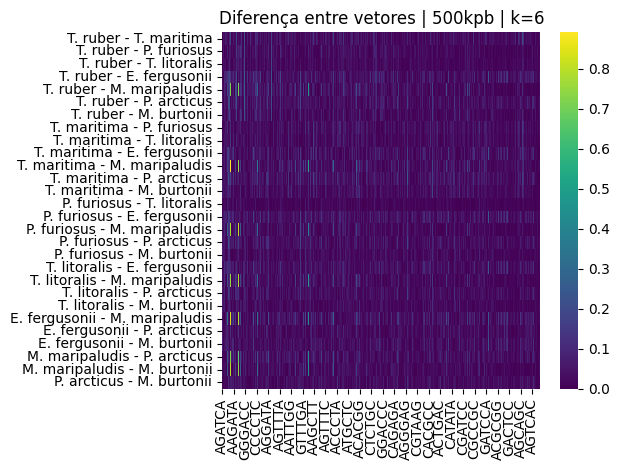

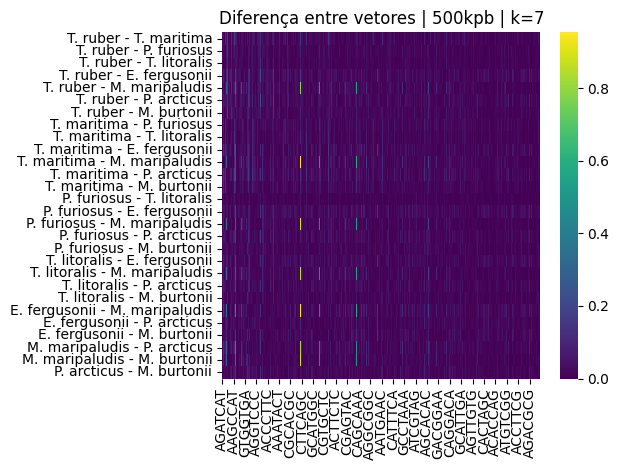

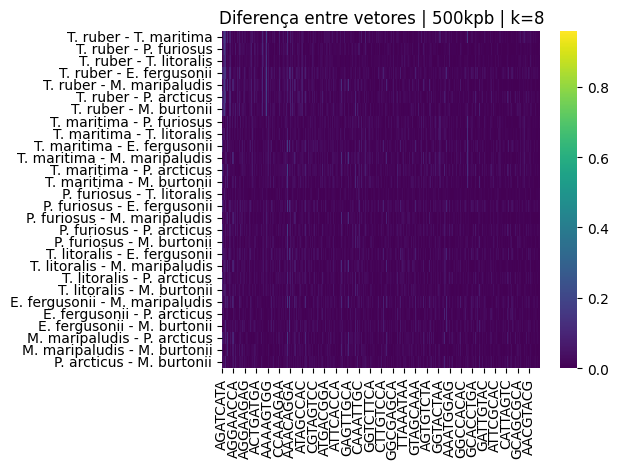

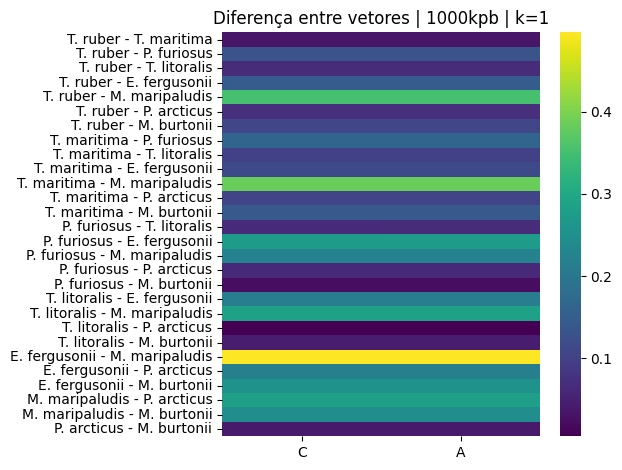

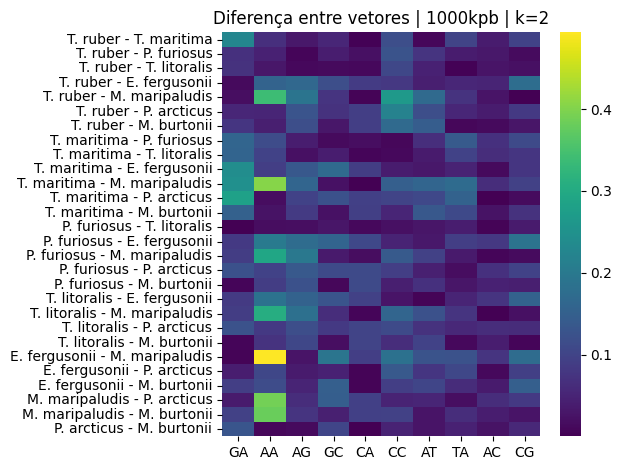

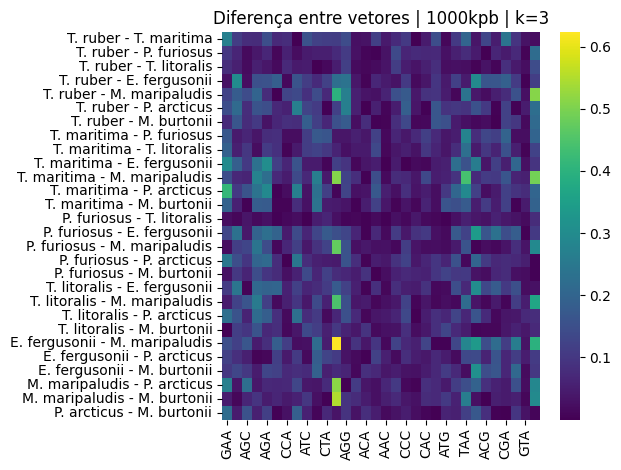

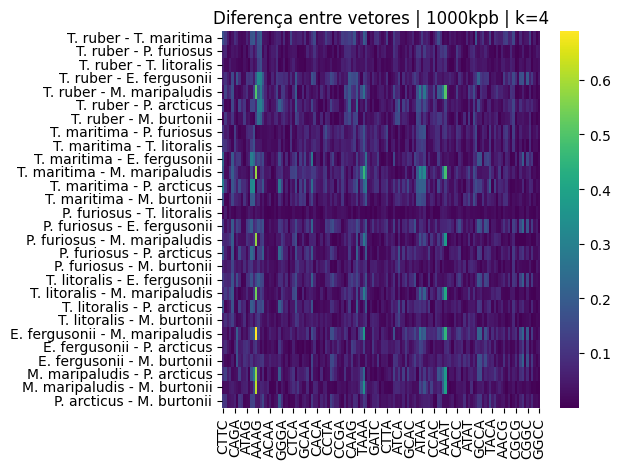

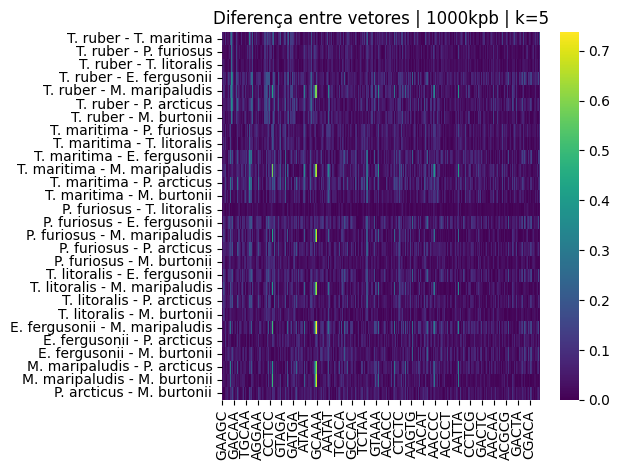

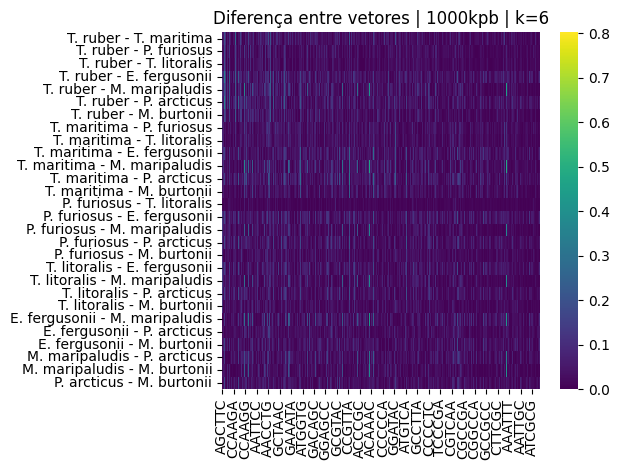

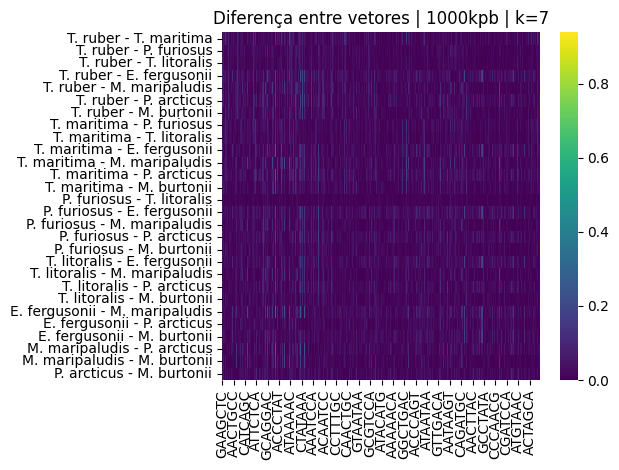

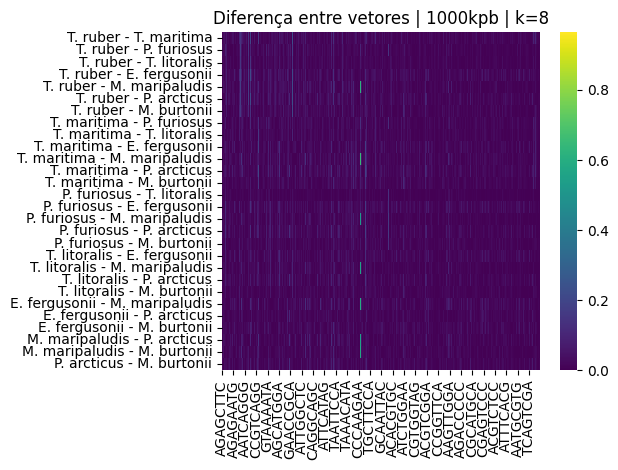

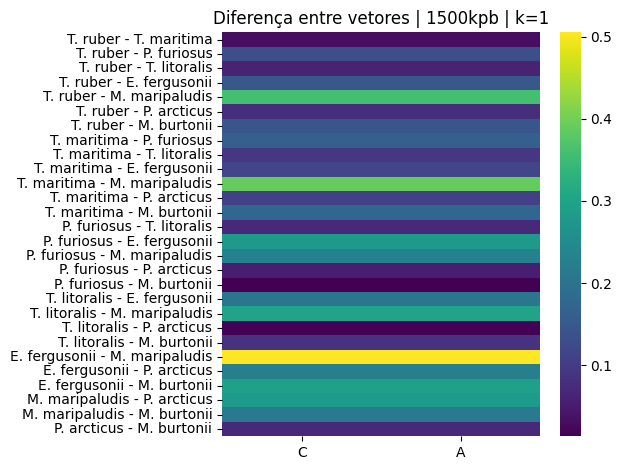

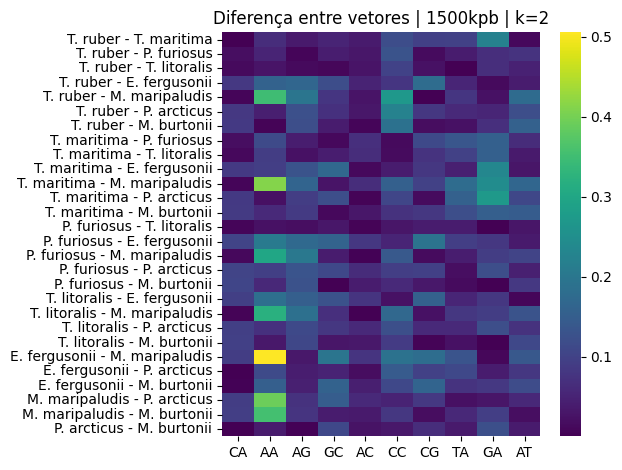

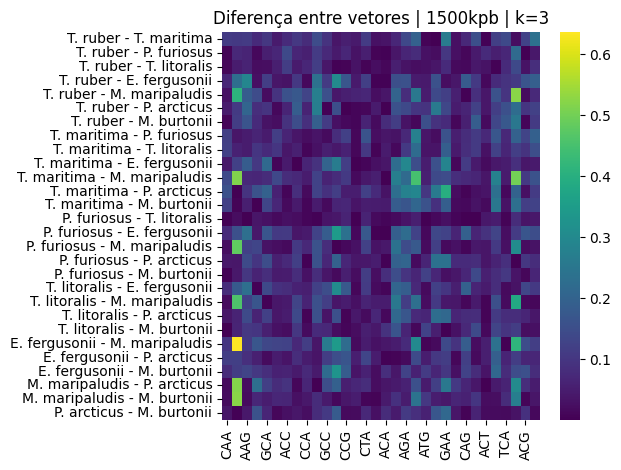

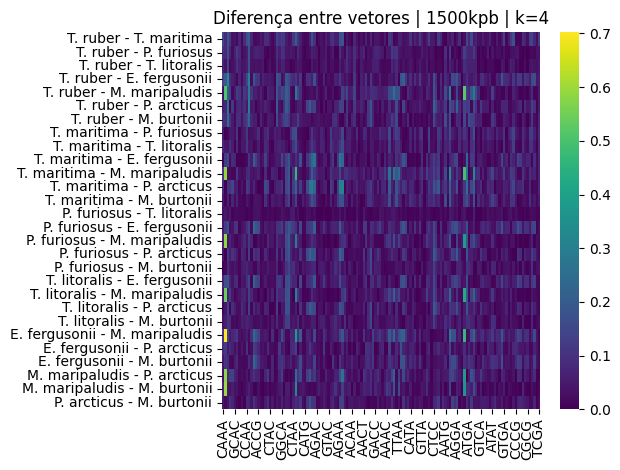

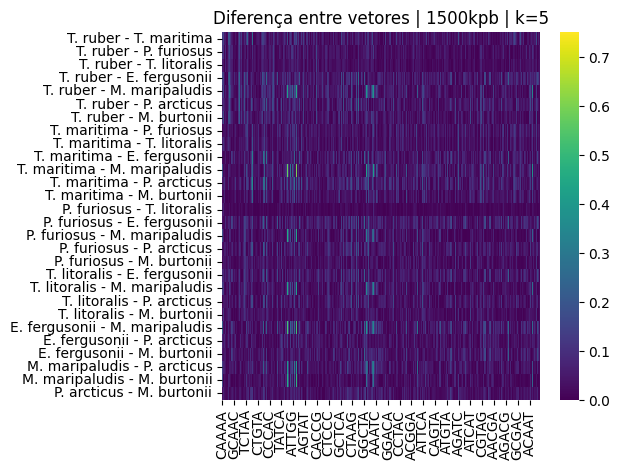

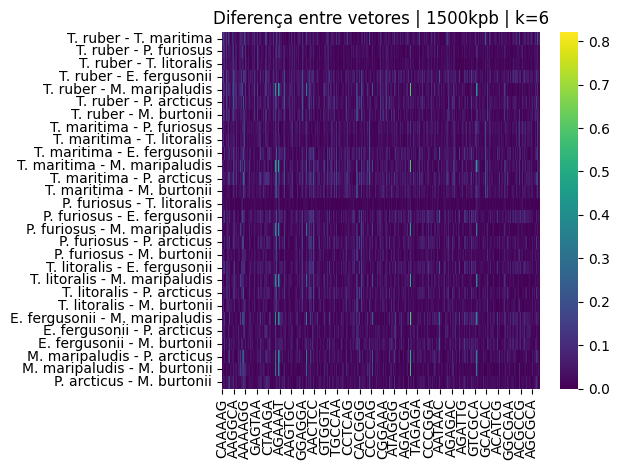

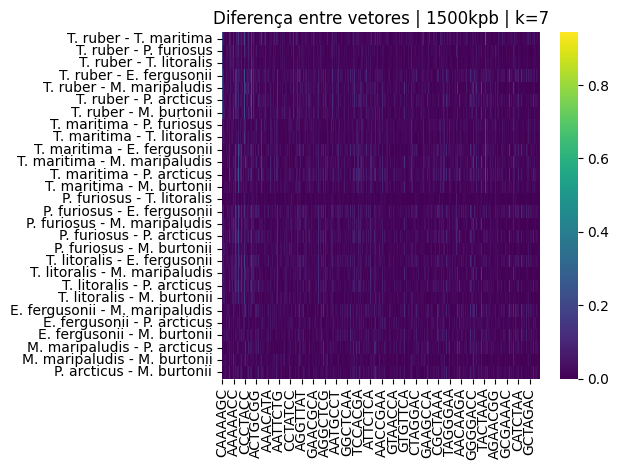

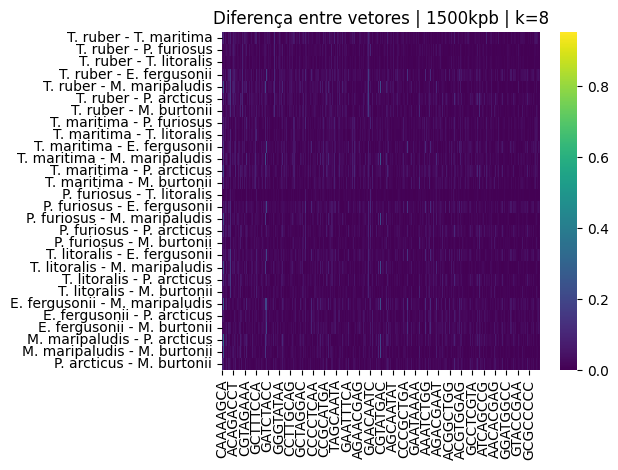

In [45]:
for tam in TAMANHOS_FRAGMENTO:
  for k in [1, 2, 3, 4, 5, 6, 7, 8]:
    nome_arq = f'resultados/vetores_frag{tam//1000}kbp_k{k}.csv'
    df = pd.read_csv(nome_arq)
    kmers = df.columns[3:]
    global_min = df[kmers].min().min()
    global_max = df[kmers].max().max()

    df[kmers] = (df[kmers] - global_min) / (global_max - global_min)
    df_result = pd.DataFrame({
        f"{df.loc[i, 'organismo']} - {df.loc[j, 'organismo']}": (df.loc[i, kmers] - df.loc[j, kmers]).abs()
        for i, j in itertools.combinations(df.index, 2)
    }).T

    df_result = df_result.astype(float)

    ax = sns.heatmap(df_result, cmap="viridis")
    ax.set_yticks([i + 0.5 for i in range(len(df_result.index))])
    ax.set_yticklabels(df_result.index, rotation=0)
    plt.title(f"Diferença entre vetores | {tam//1000}kpb | k={k}")

    plt.tight_layout()
    plt.show()

    print()